# Notebook 06 — Hedge-Efficiency Frontiers

## 1. Problem Statement

This notebook answers: **what is the most capital-efficient way to hedge perpetual-futures funding-rate tail risk?**

This is a **multi-objective decision problem** — there is no single "best hedge" without specifying a risk constraint or cost budget. The frontiers below show trade-offs; the choice map (Section 8) collapses them to recommendations.

**Key results:**
- At $k=10\%$ annual cost-of-capital, unhedged reserves cost **~3 bps per 30d**; options cost **90–130 bps**. Options have negative net benefit at conventional capital costs.
- Break-even $k^*$ for options is **~450–530%** — options are justified by **tail-risk aversion**, not capital savings.
- If target CVaR $\leq 1.5\%$, swaps cannot achieve it; **options (ASL/Floor) are required**.
- If target CVaR $\geq 2.0\%$, a **partial swap ($h \approx 0.3$-$0.4$) is cheapest** at $k=10\%$.
- **ASL q95** is the most capital-efficient option product (Eff$_A = 2.70$) across all pricing functionals.

### Notation and Definitions

All quantities are expressed as **% of notional over a 30-day window** unless noted.

| Symbol | Meaning |
|--------|---------|
| $f_i$ | Per-interval (8h) funding cashflow |
| $\Lambda$ | Aggregate reserve draw $= \sum \max(0, -f_i)$ over the window |
| $h$ | Hedge ratio $\in [0,1]$: fraction of exposure hedged |
| $\Pi$ | Hedge payoff over the window (product-specific) |
| $\pi$ | Premium paid for the hedge (deterministic) |
| $R_\alpha$ | Reserve requirement $= \text{CVaR}_{1\%}$ of residual loss |
| $M_\alpha$ | Swap margin proxy $= \text{CVaR}_{1\%}(\max(0, -X^{\text{swap}}))$ |
| $k$ | Annual cost-of-capital rate |
| $T$ | Horizon in days (30) |

**Two lenses:**
- **Lens A (Net CF):** $\text{NetCF} = \sum f_i + h \cdot \Pi - h \cdot \pi$. Answers: does hedging destroy carry?
- **Lens B (Reserve draw):** Residual loss $\tilde{L} = \max(0, \Lambda - h \cdot \Pi)$ for options; $\sum \max(0, -(1-h)f_i - hk)$ for swaps. Premium is excluded — it is a deterministic expense, not stochastic risk.

**Capital metrics:**
$$\text{Eff}_A = \frac{R_\alpha(0) - R_\alpha(h)}{h \cdot \pi}, \quad \text{Cost}_B = h\pi + k\frac{T}{365}(R_\alpha + M_\alpha), \quad k^* = \frac{h\pi}{(T/365)(R_\alpha(0) - R_\alpha(h) - M_\alpha)}$$

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

try:
    _nb_path = Path(__vsc_ipynb_file__).resolve().parent.parent
except NameError:
    _nb_path = Path.cwd()
    if _nb_path.name == "notebooks":
        _nb_path = _nb_path.parent
import os; os.chdir(str(_nb_path))
REPO_ROOT = Path(os.getcwd()).resolve()
os.makedirs(str(REPO_ROOT / "reports" / "figures"), exist_ok=True)

from ddx.data.io import load_processed
from ddx.backtest.rolling import rolling_windows_regular
from ddx.backtest.hedges import estimate_swap_rate
from ddx.payoffs import vanilla_floor, distress_activated_floor, aggregate_stop_loss
from ddx.pricing.premium import compute_premium, full_premium
from ddx.risk.metrics import total_loss, cvar, prob_loss
from ddx.capital import reserve_requirement, efficiency_A, total_economic_cost, swap_margin_proxy
from ddx.models.cluster_semi_markov import extract_episodes_and_clusters, fit_cluster_tail, simulate_semi_markov
from ddx.calibration import lambda_quantiles_per_horizon, daf_activation_analysis
from ddx.bootstrap import circular_block_bootstrap
from ddx.utils.units import INTERVALS_PER_YEAR

df = load_processed("data/processed/bybit_btcusd.parquet")
funding_cf = df["funding_cf"].values
is_regular = df["is_regular"].values
timestamps = pd.to_datetime(df["timestamp"])
n_total = len(funding_cf)

HORIZON_30D = 90; HORIZON_7D = 21; HORIZON_90D = 270
ALPHA = 0.01; CAP = 0.00375
SWAP_LOOKBACK = 90; SWAP_HALFLIFE = 45
RNG_SEED = 42

config = {"ALPHA": ALPHA, "HORIZON": "30d (90 intervals)", "H_GRID": "0.0 to 1.0 step 0.1",
          "SWAP_LOOKBACK": SWAP_LOOKBACK, "SWAP_HALFLIFE": SWAP_HALFLIFE,
          "k_values": "10%, 20%, 30% (extended to 700% for break-even)", "RNG_SEED": RNG_SEED}
print("Experiment config:")
for k, v in config.items():
    print(f"  {k}: {v}")
print(f"\nBybit: {n_total} intervals, {timestamps.iloc[0].date()} to {timestamps.iloc[-1].date()} (~{n_total*8/(24*365):.1f} yr)")

Experiment config:
  ALPHA: 0.01
  HORIZON: 30d (90 intervals)
  H_GRID: 0.0 to 1.0 step 0.1
  SWAP_LOOKBACK: 90
  SWAP_HALFLIFE: 45
  k_values: 10%, 20%, 30% (extended to 700% for break-even)
  RNG_SEED: 42

Bybit: 7971 intervals, 2018-11-15 to 2026-02-23 (~7.3 yr)


## 2. Data and Nonstationarity

The chart below demonstrates three properties that make pricing unstable:
1. **Regime shifts** in the probability of negative funding (9%–29% across eras)
2. **Volatility clustering** — stress episodes are concentrated, not uniformly distributed
3. **Structural breaks** around major events (COVID crash March 2020, FTX collapse November 2022)

Shaded regions mark approximate stress regimes (early volatile era vs later calm era). This motivates why all results carry uncertainty bands and why walk-forward evaluation is mandatory.

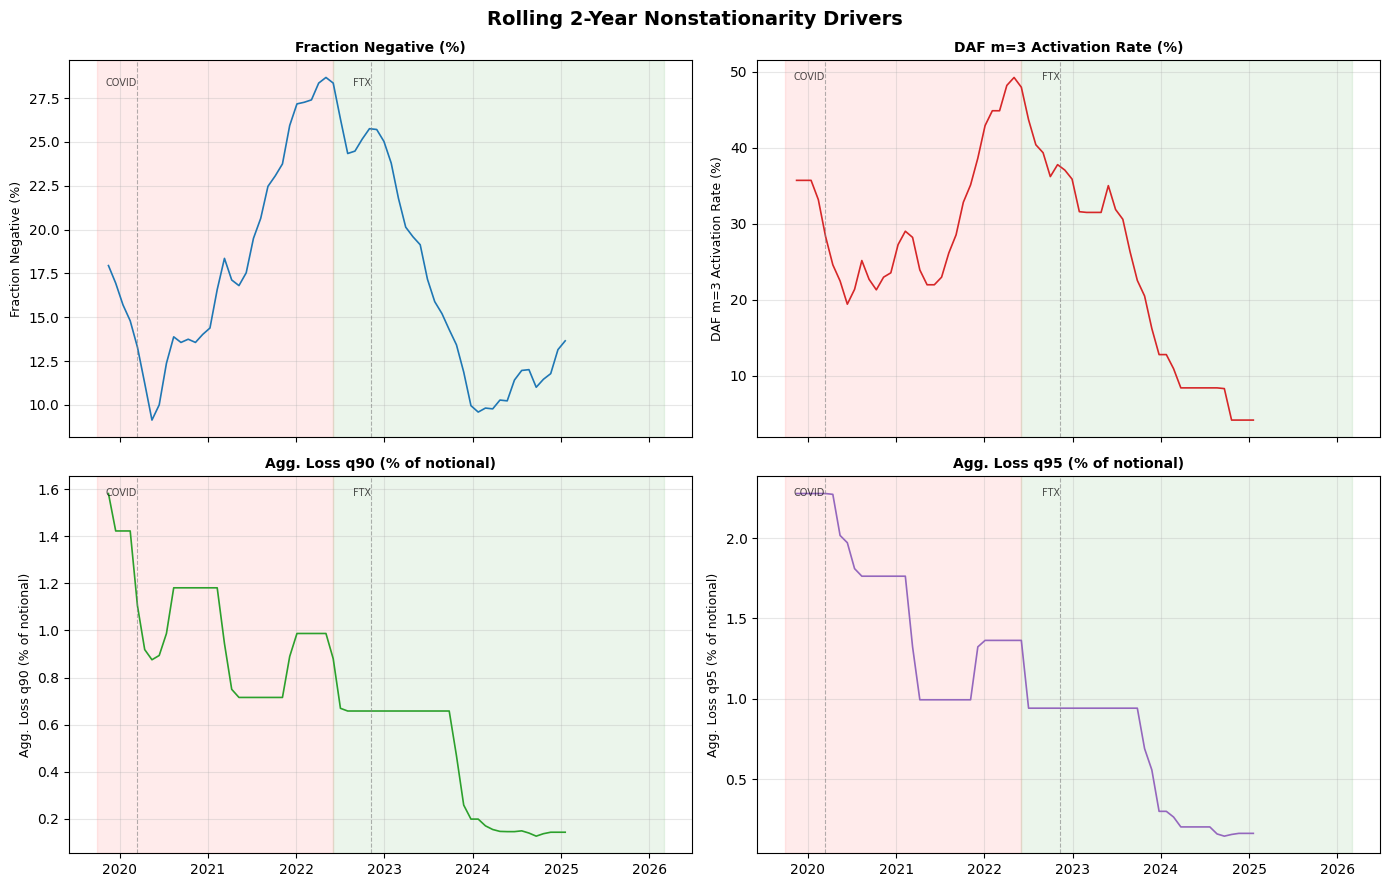

In [2]:
# Rolling 2-year nonstationarity drivers (C6: units, labels, regime shading)
ROLL_WINDOW = 2 * 365 * 3; ROLL_STEP = 90
roll_starts = list(range(0, n_total - ROLL_WINDOW - HORIZON_30D, ROLL_STEP))
roll_centers, roll_frac_neg, roll_daf_act, roll_lq90, roll_lq95 = [], [], [], [], []
for s in roll_starts:
    sub_cf = funding_cf[s:s+ROLL_WINDOW]; sub_reg = is_regular[s:s+ROLL_WINDOW]
    roll_centers.append(timestamps.iloc[min(s + ROLL_WINDOW//2, n_total-1)])
    roll_frac_neg.append(float(np.mean(sub_cf < 0)))
    daf_info = daf_activation_analysis(sub_cf, sub_reg, HORIZON_30D, threshold_b=0.0001, streak_m=3)
    roll_daf_act.append(daf_info.get("frac_windows_activated", 0.0))
    lq = lambda_quantiles_per_horizon(sub_cf, sub_reg, HORIZON_30D, quantiles=[0.90, 0.95])
    roll_lq90.append(lq["q90"]); roll_lq95.append(lq["q95"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
panels = [(roll_frac_neg,"Fraction Negative (%)","#1f77b4"),
          (roll_daf_act,"DAF m=3 Activation Rate (%)","#d62728"),
          (roll_lq90,"Agg. Loss q90 (% of notional)","#2ca02c"),
          (roll_lq95,"Agg. Loss q95 (% of notional)","#9467bd")]
for ax, (data, label, color) in zip(axes.flat, panels):
    ax.plot(roll_centers, [d*100 for d in data], linewidth=1.2, color=color)
    ax.set_ylabel(label, fontsize=9); ax.set_title(label, fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)
    # Regime shading
    ax.axvspan(pd.Timestamp("2019-10-01"), pd.Timestamp("2022-06-01"), alpha=0.08, color="red", label="Volatile era")
    ax.axvspan(pd.Timestamp("2022-06-01"), pd.Timestamp("2026-03-01"), alpha=0.08, color="green", label="Calm era")
    for ev_date, ev_label in [("2020-03-12","COVID"),("2022-11-08","FTX")]:
        ax.axvline(pd.Timestamp(ev_date), color="gray", ls="--", alpha=0.6, lw=0.8)
        ax.text(pd.Timestamp(ev_date), ax.get_ylim()[1]*0.95, ev_label, fontsize=7, alpha=0.7, ha="right")
fig.suptitle("Rolling 2-Year Nonstationarity Drivers", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/rolling_drivers_2y.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

### Distribution of 30d aggregate reserve draw ($\Lambda$)

The histogram shows how heavy-tailed $\Lambda$ is — most windows have small losses, but the worst 1% exceeds 2.9% of notional. This tail is what drives premium costs and reserve requirements.

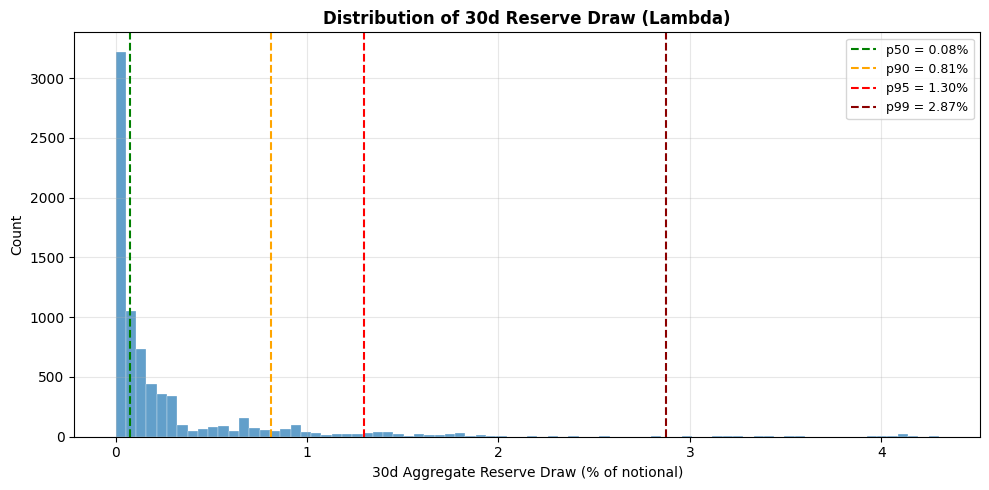

Windows: 7634. Lambda: mean=0.273%, p50=0.077%, p90=0.811%, p99=2.875%
Net CF: mean=0.947%, P(loss)=15.2%


In [3]:
# B2: Lambda histogram
windows_30d, win_starts_30d = rolling_windows_regular(funding_cf, is_regular, HORIZON_30D)
n_windows = len(windows_30d)
lambda_per_window = np.array([total_loss(w) for w in windows_30d])
netcf_per_window = np.array([float(np.sum(w)) for w in windows_30d])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(lambda_per_window*100, bins=80, color="#1f77b4", alpha=0.7, edgecolor="white", linewidth=0.3)
for q, label, color in [(0.50,"p50","green"),(0.90,"p90","orange"),(0.95,"p95","red"),(0.99,"p99","darkred")]:
    val = np.quantile(lambda_per_window, q)*100
    ax.axvline(val, color=color, ls="--", lw=1.5, label=f"{label} = {val:.2f}%")
ax.set_xlabel("30d Aggregate Reserve Draw (% of notional)"); ax.set_ylabel("Count")
ax.set_title("Distribution of 30d Reserve Draw (Lambda)", fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/lambda_histogram.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")
print(f"Windows: {n_windows}. Lambda: mean={lambda_per_window.mean()*100:.3f}%, p50={np.median(lambda_per_window)*100:.3f}%, "
      f"p90={np.quantile(lambda_per_window,0.90)*100:.3f}%, p99={np.quantile(lambda_per_window,0.99)*100:.3f}%")
print(f"Net CF: mean={netcf_per_window.mean()*100:.3f}%, P(loss)={prob_loss(netcf_per_window)*100:.1f}%")

## 3. Hedge Products

### Payoff definitions
- **Floor:** Pays $\sum \max(0, -f_i - d)$ per window. Insurance against every negative interval exceeding deductible $d$.
- **DAF (Distress-Activated Floor):** Same as Floor, but only pays after $m$ consecutive intervals where $f_i < -b$. Filters noise; pays only during sustained distress. *(Path-dependent: payoff depends on the sequence, not just $\Lambda$.)*
- **ASL (Aggregate Stop-Loss):** Pays $\max(0, \Lambda - D)$ on total period loss. Reinsurance-style tail layer above deductible $D$.
- **Swap:** Locks funding at trailing-estimated fixed rate $k$. Eliminates variability (both upside and downside). Trailing EWMA locks in carry at the prevailing realized carry proxy — the closest liquid approximation to a swap fixed rate. **No lookahead:** swap rate at window $t$ uses only history up to start of $t$.

In [4]:
# Strategy table (C3: adds "Pays when" column)
ASL_D_30D_Q90 = 0.008114; ASL_D_30D_Q95 = 0.012967
ASL_D_7D_Q90 = 0.001701; ASL_D_7D_Q95 = 0.003153
ASL_D_90D_Q90 = 0.023236; ASL_D_90D_Q95 = 0.029158
H_GRID = [round(x, 1) for x in np.arange(0, 1.05, 0.1).tolist()]

stbl = pd.DataFrame([
    {"Strategy":"Unhedged","Type":"Baseline","Pays when":"—","Key param":"—"},
    {"Strategy":"Swap (EWMA)","Type":"Linear","Pays when":"Always (replaces stream)","Key param":"lookback=90, hl=45"},
    {"Strategy":"Swap (mean)","Type":"Linear","Pays when":"Always (replaces stream)","Key param":"lookback=90"},
    {"Strategy":"Floor d=0.0001","Type":"Option","Pays when":"Any interval f_i < -d","Key param":"d=0.0001 (10.95% APR)"},
    {"Strategy":"Floor d=0.0003","Type":"Option","Pays when":"Any interval f_i < -d","Key param":"d=0.0003 (32.85% APR)"},
    {"Strategy":"DAF m=3","Type":"Option","Pays when":"3+ consec. intervals f_i < -b","Key param":"b=d=0.0001, m=3"},
    {"Strategy":"DAF m=2","Type":"Option","Pays when":"2+ consec. intervals f_i < -b","Key param":"b=d=0.0001, m=2"},
    {"Strategy":"ASL q90","Type":"Option","Pays when":"Total loss Lambda > D","Key param":f"D={ASL_D_30D_Q90:.4f} (q90)"},
    {"Strategy":"ASL q95","Type":"Option","Pays when":"Total loss Lambda > D","Key param":f"D={ASL_D_30D_Q95:.4f} (q95)"},
])
print(stbl.to_string(index=False))

      Strategy     Type                     Pays when             Key param
      Unhedged Baseline                             —                     —
   Swap (EWMA)   Linear      Always (replaces stream)    lookback=90, hl=45
   Swap (mean)   Linear      Always (replaces stream)           lookback=90
Floor d=0.0001   Option         Any interval f_i < -d d=0.0001 (10.95% APR)
Floor d=0.0003   Option         Any interval f_i < -d d=0.0003 (32.85% APR)
       DAF m=3   Option 3+ consec. intervals f_i < -b       b=d=0.0001, m=3
       DAF m=2   Option 2+ consec. intervals f_i < -b       b=d=0.0001, m=2
       ASL q90   Option         Total loss Lambda > D        D=0.0081 (q90)
       ASL q95   Option         Total loss Lambda > D        D=0.0130 (q95)


### Payoff diagrams vs realized $\Lambda$

Each point is one 30d window. The x-axis is the realized reserve draw $\Lambda$; the y-axis is the hedge payoff. This shows *when* each product pays and *how much*.

- **Floor** (green): pays on almost every window with positive $\Lambda$, linearly increasing.
- **ASL** (purple): zero until $\Lambda$ exceeds the deductible $D$, then pays the excess — a "tail layer."
- **DAF** (red): path-dependent — some windows with high $\Lambda$ have zero DAF payoff because losses weren't consecutive. The cloud below the Floor line shows the persistence filter at work.

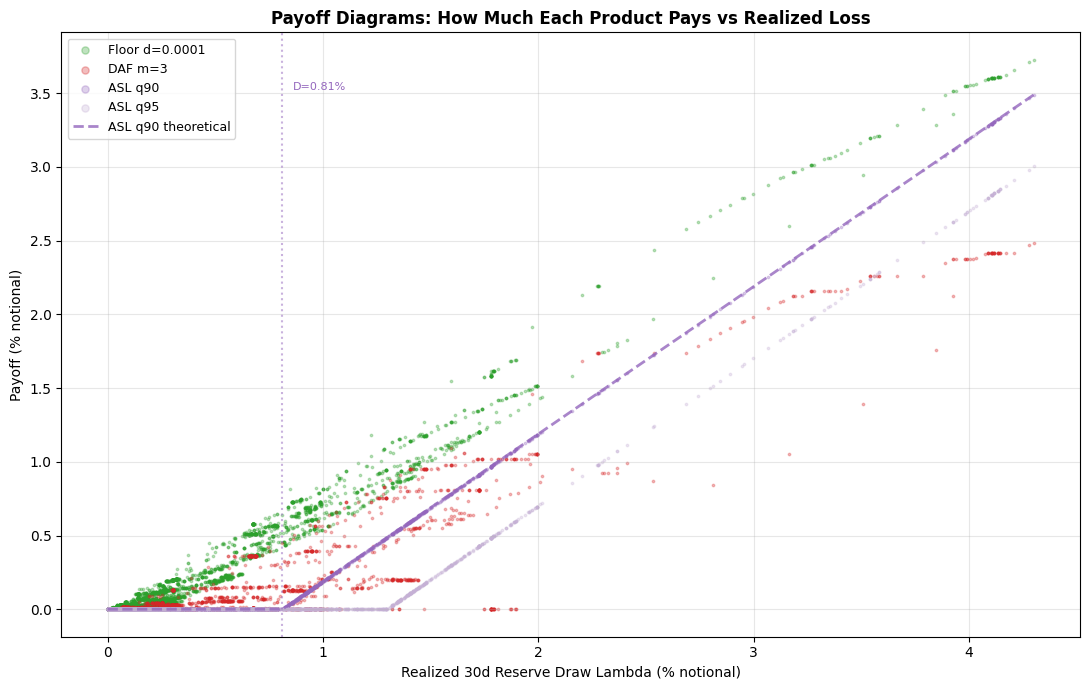

In [5]:
# B1: Payoff diagrams vs Lambda
payoff_arrays = {}
payoff_arrays["Floor d=0.0001"] = np.array([vanilla_floor(w, deductible=0.0001) for w in windows_30d])
payoff_arrays["Floor d=0.0003"] = np.array([vanilla_floor(w, deductible=0.0003) for w in windows_30d])
payoff_arrays["DAF m=3"] = np.array([distress_activated_floor(w, threshold_b=0.0001, streak_m=3, deductible=0.0001) for w in windows_30d])
payoff_arrays["DAF m=2"] = np.array([distress_activated_floor(w, threshold_b=0.0001, streak_m=2, deductible=0.0001) for w in windows_30d])
payoff_arrays["ASL q90"] = np.array([aggregate_stop_loss(w, deductible_D=ASL_D_30D_Q90) for w in windows_30d])
payoff_arrays["ASL q95"] = np.array([aggregate_stop_loss(w, deductible_D=ASL_D_30D_Q95) for w in windows_30d])

COLORS = {"Unhedged":"#888888","Swap (EWMA)":"#1f77b4","Swap (mean)":"#aec7e8",
          "Floor d=0.0001":"#2ca02c","Floor d=0.0003":"#98df8a",
          "DAF m=3":"#d62728","DAF m=2":"#ff9896","ASL q90":"#9467bd","ASL q95":"#c5b0d5"}

fig, ax = plt.subplots(figsize=(11, 7))
order = np.argsort(lambda_per_window)
for name in ["Floor d=0.0001","DAF m=3","ASL q90","ASL q95"]:
    ax.scatter(lambda_per_window[order]*100, payoff_arrays[name][order]*100,
               s=3, alpha=0.3, color=COLORS[name], label=name)
# ASL theoretical line
lam_range = np.linspace(0, lambda_per_window.max(), 200)
ax.plot(lam_range*100, np.maximum(0, lam_range - ASL_D_30D_Q90)*100, "--", color=COLORS["ASL q90"], alpha=0.8, linewidth=2, label="ASL q90 theoretical")
ax.axvline(ASL_D_30D_Q90*100, color=COLORS["ASL q90"], ls=":", alpha=0.5)
ax.text(ASL_D_30D_Q90*100+0.05, ax.get_ylim()[1]*0.9, f"D={ASL_D_30D_Q90*100:.2f}%", fontsize=8, color=COLORS["ASL q90"])
ax.set_xlabel("Realized 30d Reserve Draw Lambda (% notional)"); ax.set_ylabel("Payoff (% notional)")
ax.set_title("Payoff Diagrams: How Much Each Product Pays vs Realized Loss", fontweight="bold")
ax.legend(fontsize=9, markerscale=3); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/payoff_diagrams.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

### Pricing Protocol and Premium Decomposition

Premium = Pure + CVaR risk load ($\lambda=0.35$) + capital charge ($k_c=12\%$). The risk load dominates — it is 7–22$\times$ the pure premium because the payoff distribution is extremely heavy-tailed.

Swap rates are estimated **per window** using trailing EWMA/mean ending at each window start (**no lookahead**).

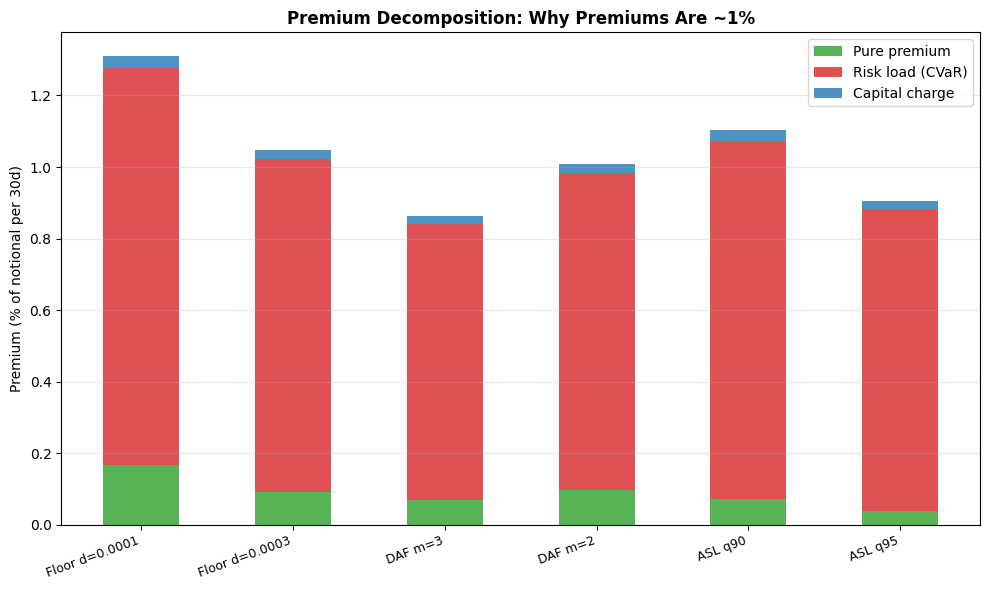

Computing per-window swap rates (no lookahead)...



Premiums (% notional):
  Floor d=0.0001      : 1.3110%  (pure 0.1681, risk_load 1.1100, cap 0.0329)
  Floor d=0.0003      : 1.0482%  (pure 0.0918, risk_load 0.9293, cap 0.0271)
  DAF m=3             : 0.8641%  (pure 0.0695, risk_load 0.7721, cap 0.0224)
  DAF m=2             : 1.0095%  (pure 0.0959, risk_load 0.8877, cap 0.0260)
  ASL q90             : 1.1024%  (pure 0.0719, risk_load 1.0016, cap 0.0289)
  ASL q95             : 0.9061%  (pure 0.0386, risk_load 0.8434, cap 0.0241)

Swap rate summary (per-window, no lookahead):
Swap Min APR Median APR Max APR Frac Neg
EWMA  -46.7%       7.6%  160.1%    16.2%
Mean  -49.2%       7.7%  136.9%    15.9%

R_alpha (unhedged CVaR 1%): 3.7449%


In [6]:
# Compute premiums + decomposition
premiums = {}; prem_decomp = {}
for name, payoffs in payoff_arrays.items():
    det = full_premium(payoffs)
    premiums[name] = det["total"]
    prem_decomp[name] = det

# B3: Premium decomposition bar chart
fig, ax = plt.subplots(figsize=(10, 6))
names = list(payoff_arrays.keys())
pures = [prem_decomp[n]["pure"]*100 for n in names]
rls = [prem_decomp[n]["risk_load"]*100 for n in names]
ccs = [prem_decomp[n]["capital_charge"]*100 for n in names]
x = np.arange(len(names))
ax.bar(x, pures, 0.5, label="Pure premium", color="#2ca02c", alpha=0.8)
ax.bar(x, rls, 0.5, bottom=pures, label="Risk load (CVaR)", color="#d62728", alpha=0.8)
ax.bar(x, ccs, 0.5, bottom=[p+r for p,r in zip(pures,rls)], label="Capital charge", color="#1f77b4", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Premium (% of notional per 30d)"); ax.set_title("Premium Decomposition: Why Premiums Are ~1%", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y"); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/premium_decomposition.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

# Per-window swap rates
print("Computing per-window swap rates (no lookahead)...")
swap_ewma_rates = np.array([estimate_swap_rate(funding_cf, SWAP_LOOKBACK, s, method="ewma", halflife=SWAP_HALFLIFE) for s in win_starts_30d])
swap_mean_rates = np.array([estimate_swap_rate(funding_cf, SWAP_LOOKBACK, s, method="mean") for s in win_starts_30d])

R_unhedged = reserve_requirement(lambda_per_window, alpha=ALPHA)

# Print summary
print(f"\nPremiums (% notional):")
for name, p in premiums.items():
    d = prem_decomp[name]
    print(f"  {name:20s}: {p*100:.4f}%  (pure {d['pure']*100:.4f}, risk_load {d['risk_load']*100:.4f}, cap {d['capital_charge']*100:.4f})")

sr_tbl = pd.DataFrame([
    {"Swap":"EWMA","Min APR":f"{swap_ewma_rates.min()*INTERVALS_PER_YEAR*100:.1f}%",
     "Median APR":f"{np.median(swap_ewma_rates)*INTERVALS_PER_YEAR*100:.1f}%",
     "Max APR":f"{swap_ewma_rates.max()*INTERVALS_PER_YEAR*100:.1f}%",
     "Frac Neg":f"{(swap_ewma_rates<0).mean()*100:.1f}%"},
    {"Swap":"Mean","Min APR":f"{swap_mean_rates.min()*INTERVALS_PER_YEAR*100:.1f}%",
     "Median APR":f"{np.median(swap_mean_rates)*INTERVALS_PER_YEAR*100:.1f}%",
     "Max APR":f"{swap_mean_rates.max()*INTERVALS_PER_YEAR*100:.1f}%",
     "Frac Neg":f"{(swap_mean_rates<0).mean()*100:.1f}%"},
])
print(f"\nSwap rate summary (per-window, no lookahead):"); print(sr_tbl.to_string(index=False))
print(f"\nR_alpha (unhedged CVaR 1%): {R_unhedged*100:.4f}%")

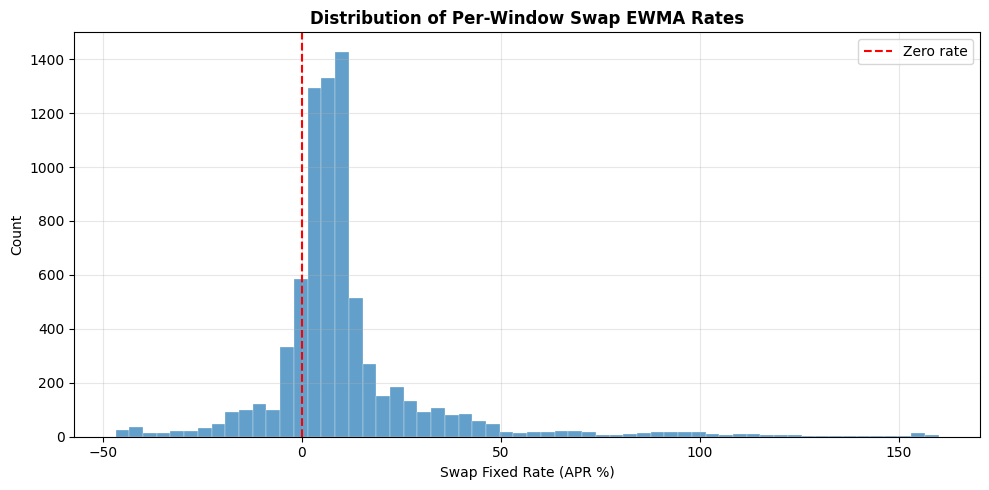

Swap EWMA: 16.2% of windows have negative rate (swap locks in loss)


In [7]:
# B4: Swap rate histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(swap_ewma_rates*INTERVALS_PER_YEAR*100, bins=60, color="#1f77b4", alpha=0.7, edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", ls="--", lw=1.5, label="Zero rate")
ax.set_xlabel("Swap Fixed Rate (APR %)"); ax.set_ylabel("Count")
ax.set_title("Distribution of Per-Window Swap EWMA Rates", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/swap_rate_histogram.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")
print(f"Swap EWMA: {(swap_ewma_rates<0).mean()*100:.1f}% of windows have negative rate (swap locks in loss)")

## 4. Point Estimates at $h=1$ (Master Summary Table)

This table orients the reader before the frontier plots. It shows every strategy at full hedge, with both reserve-draw and net-CF metrics, plus the break-even cost-of-capital $k^*$.

Total cost is expressed in **basis points (bps) per 30d** because capital charges and premiums differ by orders of magnitude at $k=10\%$.

In [8]:
# Compute frontier (B11: exact swap margin at all h)
frontier_rows = []

# Unhedged
for h in H_GRID:
    frontier_rows.append({"strategy":"Unhedged","h":h,"premium":0,"cvar_01_loss":R_unhedged,
        "reserve_reduction":0,"eff_A":0,"margin":0,
        "cost_k10":total_economic_cost(0,R_unhedged,0.10,30),
        "cost_k20":total_economic_cost(0,R_unhedged,0.20,30),
        "mean_loss":float(np.mean(lambda_per_window))})

# Swaps: exact per-interval blended loss + exact margin
for swap_name, s_rates in [("Swap (EWMA)", swap_ewma_rates), ("Swap (mean)", swap_mean_rates)]:
    for h in H_GRID:
        # Exact residual loss
        blended_losses = np.array([float(np.sum(np.maximum(0.0, -((1-h)*w + h*s_rates[idx])))) for idx, w in enumerate(windows_30d)])
        r_h = reserve_requirement(blended_losses, alpha=ALPHA)
        # Exact margin: CVaR of swap-portion losses
        swap_portion_cfs = np.array([(1-h)*float(np.sum(w)) + h*float(len(w))*s_rates[idx] for idx, w in enumerate(windows_30d)])
        swap_losses_h = np.maximum(0.0, -swap_portion_cfs) * (h if h > 0 else 0)
        m_h = reserve_requirement(np.maximum(0.0, -np.array([float(len(w))*s_rates[idx]*h for idx, w in enumerate(windows_30d)])), alpha=ALPHA) if h > 0 else 0.0
        cost_10 = total_economic_cost(0, r_h + m_h, 0.10, 30)
        cost_20 = total_economic_cost(0, r_h + m_h, 0.20, 30)
        frontier_rows.append({"strategy":swap_name,"h":h,"premium":0,"cvar_01_loss":r_h,
            "reserve_reduction":R_unhedged-r_h,"eff_A":0,"margin":m_h,
            "cost_k10":cost_10,"cost_k20":cost_20,"mean_loss":float(np.mean(blended_losses))})

# Options
for name in payoff_arrays:
    for h in H_GRID:
        residual = np.maximum(0.0, lambda_per_window - h*payoff_arrays[name])
        r_h = reserve_requirement(residual, alpha=ALPHA)
        prem_h = h * premiums[name]
        eff_a = efficiency_A(R_unhedged, r_h, prem_h) if h > 0 else 0.0
        cost_10 = total_economic_cost(prem_h, r_h, 0.10, 30)
        cost_20 = total_economic_cost(prem_h, r_h, 0.20, 30)
        frontier_rows.append({"strategy":name,"h":h,"premium":prem_h,"cvar_01_loss":r_h,
            "reserve_reduction":R_unhedged-r_h,"eff_A":eff_a,"margin":0,
            "cost_k10":cost_10,"cost_k20":cost_20,"mean_loss":float(np.mean(residual))})

frontier_df = pd.DataFrame(frontier_rows)

# h=1 master table (C12: net CF + premium decomp + bps)
h1 = frontier_df[frontier_df["h"]==1.0].copy()
# Add net CF metrics
for idx, row in h1.iterrows():
    name = row["strategy"]
    if name == "Unhedged":
        h1.loc[idx,"mean_netcf"] = netcf_per_window.mean()
        h1.loc[idx,"cvar_netcf"] = cvar(netcf_per_window, ALPHA)
    elif "Swap" in name:
        s_rates_arr = swap_ewma_rates if "EWMA" in name else swap_mean_rates
        bl = np.array([(1-1.0)*float(np.sum(w))+1.0*float(len(w))*s_rates_arr[i] for i,w in enumerate(windows_30d)])
        h1.loc[idx,"mean_netcf"] = bl.mean()
        h1.loc[idx,"cvar_netcf"] = cvar(bl, ALPHA)
    else:
        hcf = netcf_per_window + payoff_arrays[name] - premiums[name]
        h1.loc[idx,"mean_netcf"] = hcf.mean()
        h1.loc[idx,"cvar_netcf"] = cvar(hcf, ALPHA)

# Break-even k
h1["break_even_k"] = np.nan
for idx, row in h1.iterrows():
    delta_R = R_unhedged - row["cvar_01_loss"] - row["margin"]
    if row["premium"] > 0 and delta_R > 0:
        h1.loc[idx,"break_even_k"] = row["premium"] / ((30/365) * delta_R)

# Display
tbl = h1[["strategy","premium","cvar_01_loss","margin","reserve_reduction","eff_A",
          "cost_k10","mean_netcf","cvar_netcf","break_even_k"]].copy()
tbl["premium_bps"] = tbl["premium"]*10000
tbl["cost_bps"] = tbl["cost_k10"]*10000
for c in ["premium","cvar_01_loss","margin","reserve_reduction","mean_netcf","cvar_netcf"]:
    tbl[c] = tbl[c]*100
tbl["eff_A"] = tbl["eff_A"].round(2)
tbl["break_even_k"] = tbl["break_even_k"].apply(lambda x: f"{x*100:.0f}%" if pd.notna(x) else "n/a")
tbl_disp = tbl[["strategy","premium","cvar_01_loss","margin","reserve_reduction","eff_A",
                "cost_bps","mean_netcf","cvar_netcf","break_even_k"]].rename(
    columns={"strategy":"Strategy","premium":"Premium (%)","cvar_01_loss":"CVaR Resid (%)",
             "margin":"Margin (%)","reserve_reduction":"Reserve Reduc (%)","eff_A":"Eff_A",
             "cost_bps":"Cost (bps)","mean_netcf":"Mean NetCF (%)","cvar_netcf":"CVaR NetCF (%)",
             "break_even_k":"k*"})
print(tbl_disp.to_string(index=False, float_format="%.3f"))
frontier_df.to_csv(str(REPO_ROOT/"reports/tables/frontier_30d.csv"), index=False)

      Strategy  Premium (%)  CVaR Resid (%)  Margin (%)  Reserve Reduc (%)  Eff_A  Cost (bps)  Mean NetCF (%)  CVaR NetCF (%)   k*
      Unhedged        0.000           3.745       0.000              0.000  0.000       3.078           0.947          -3.187  n/a
   Swap (EWMA)        0.000           3.441       3.441              0.304  0.000       5.656           0.914          -3.441  n/a
   Swap (mean)        0.000           3.255       3.255              0.490  0.000       5.351           0.917          -3.255  n/a
Floor d=0.0001        1.311           0.533       0.000              3.212  2.450     131.542          -0.196          -1.572 497%
Floor d=0.0003        1.048           1.248       0.000              2.497  2.380     105.848          -0.010          -2.008 511%
       DAF m=3        0.864           1.752       0.000              1.993  2.310      87.851           0.152          -2.139 528%
       DAF m=2        1.010           1.416       0.000              2.328  2.310  

## 5. Hedge-Efficiency Frontiers

Three frontier views answer different questions:
1. **Premium lens** (insurance cost): "How much premium buys how much tail risk reduction?" This lens is for comparing **option products**; swaps have zero premium and belong in the economic/capital lens.
2. **Total economic cost lens** (bps): "What is the all-in flow cost including capital charges?" Converts unlike costs into a single unit.
3. **Capital-locked lens** (stock): "How much capital must be locked?" This is where swaps stop looking free — they require significant margin.

**How to read each frontier:** All curves start at $h=0$ (the unhedged anchor). Moving along each curve increases the hedge ratio $h$. The **Pareto-efficient** points (non-dominated) are highlighted — only these are "ever optimal."

In [9]:
# Compute Pareto frontier (premium lens)
MARKERS = {"Unhedged":"s","Swap (EWMA)":"^","Swap (mean)":"v",
           "Floor d=0.0001":"o","Floor d=0.0003":"D",
           "DAF m=3":"P","DAF m=2":"X","ASL q90":"*","ASL q95":"h"}

all_pts = frontier_df[frontier_df["h"] > 0][["strategy","h","cvar_01_loss","premium","cost_k10"]].copy()
pareto_mask = []
for idx, row in all_pts.iterrows():
    dominated = False
    for idx2, row2 in all_pts.iterrows():
        if idx == idx2: continue
        if (row2["cvar_01_loss"] <= row["cvar_01_loss"] and row2["premium"] <= row["premium"]
            and (row2["cvar_01_loss"] < row["cvar_01_loss"] or row2["premium"] < row["premium"])):
            dominated = True; break
    pareto_mask.append(not dominated)
all_pts["pareto"] = pareto_mask
pareto_pts = all_pts[all_pts["pareto"]].sort_values("cvar_01_loss")

print("=== Pareto-efficient points (premium lens) ===")
print(pareto_pts[["strategy","h","cvar_01_loss","premium"]].rename(
    columns={"cvar_01_loss":"CVaR (%)","premium":"Premium (%)"}).to_string(index=False, float_format="%.4f"))

# Strategies never on Pareto frontier
pareto_strats = set(pareto_pts["strategy"].unique())
all_strats = set(frontier_df["strategy"].unique())
dominated_strats = all_strats - pareto_strats - {"Unhedged"}
print(f"\nStrategies NEVER on Pareto frontier (dominated everywhere): {sorted(dominated_strats) if dominated_strats else 'None'}")

=== Pareto-efficient points (premium lens) ===
      strategy      h  CVaR (%)  Premium (%)
Floor d=0.0001 1.0000    0.0053       0.0131
Floor d=0.0001 0.9000    0.0078       0.0118
       ASL q90 1.0000    0.0081       0.0110
Floor d=0.0001 0.8000    0.0110       0.0105
       ASL q90 0.9000    0.0110       0.0099
       ASL q95 1.0000    0.0130       0.0091
       ASL q90 0.8000    0.0140       0.0088
       ASL q95 0.9000    0.0154       0.0082
       ASL q90 0.7000    0.0169       0.0077
       ASL q95 0.8000    0.0179       0.0072
   Swap (mean) 0.4000    0.0183       0.0000

Strategies NEVER on Pareto frontier (dominated everywhere): ['DAF m=2', 'DAF m=3', 'Floor d=0.0003', 'Swap (EWMA)']


### 5a. Premium Lens (Options-Focused)

This is the **insurance cost** frontier. Only option products and the unhedged anchor are shown — swaps have zero premium and cannot appear on this axis. (All-strategies version in 5b below.)

Points on the **Pareto frontier** (thick line, labeled) are non-dominated: no other (strategy, $h$) achieves both lower risk and lower premium. $h=0$, $h=0.5$, and $h=1$ are labeled on each curve.

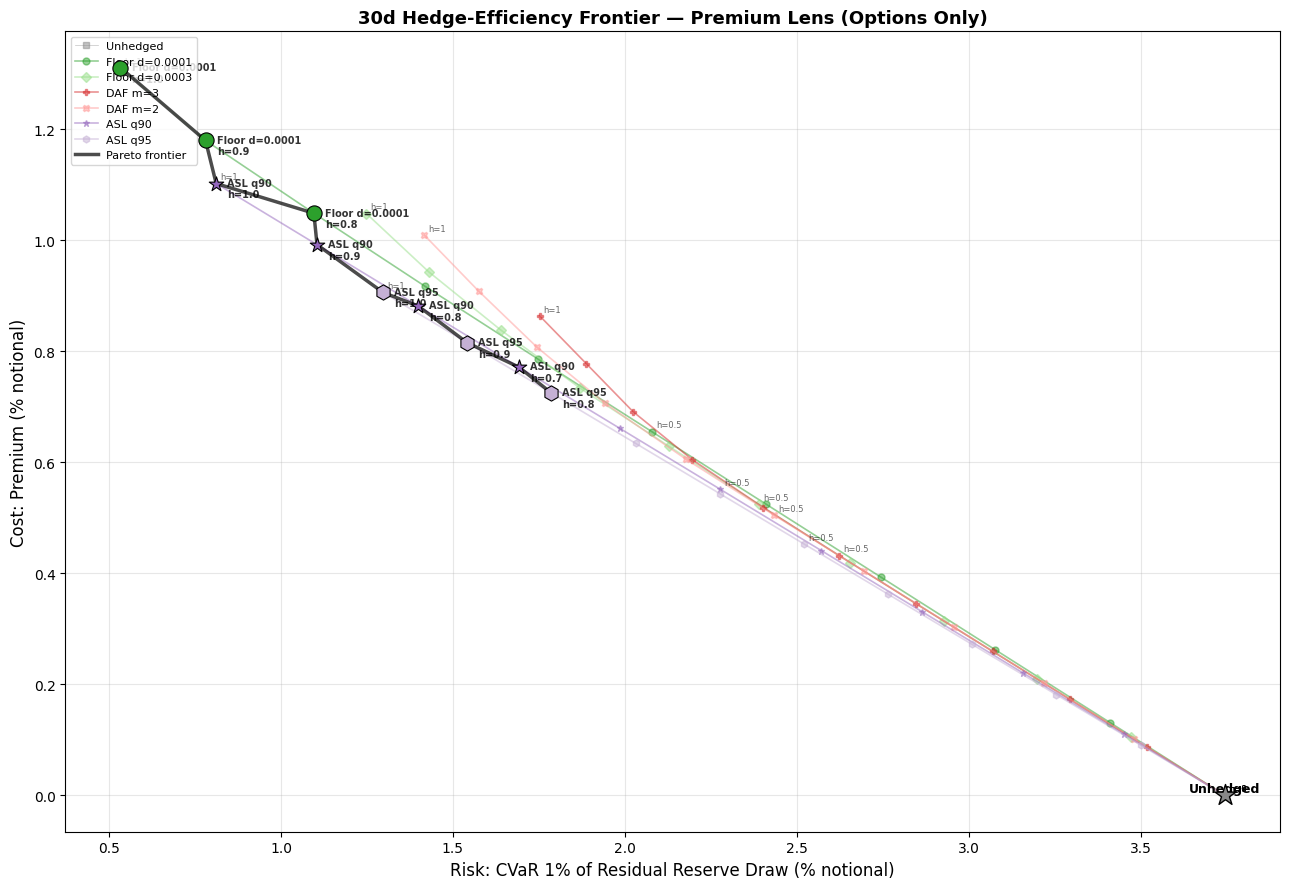

In [10]:
# C9: Premium frontier (option-only main) with Pareto labels + h markers
fig, ax = plt.subplots(figsize=(13, 9))
option_names = [s for s in frontier_df["strategy"].unique() if s not in ("Swap (EWMA)","Swap (mean)")]
for strat in option_names:
    sdf = frontier_df[frontier_df["strategy"]==strat].sort_values("h")
    ax.plot(sdf["cvar_01_loss"]*100, sdf["premium"]*100,
            marker=MARKERS.get(strat,"o"), label=strat, color=COLORS.get(strat,"#333"),
            linewidth=1.2 if strat != "Unhedged" else 0.5, markersize=5, alpha=0.5)
    # Label h=0, 0.5, 1
    for hv in [0.0, 0.5, 1.0]:
        pt = sdf[sdf["h"]==hv]
        if len(pt) > 0 and strat != "Unhedged":
            ax.annotate(f"h={hv:.0g}", (pt["cvar_01_loss"].values[0]*100, pt["premium"].values[0]*100),
                        fontsize=6, alpha=0.6, xytext=(3,3), textcoords="offset points")

# Pareto overlay with strategy labels
pp_opt = pareto_pts[~pareto_pts["strategy"].str.contains("Swap")].sort_values("cvar_01_loss")
ax.plot(pp_opt["cvar_01_loss"]*100, pp_opt["premium"]*100, "k-", linewidth=2.5, alpha=0.7, zorder=8, label="Pareto frontier")
for _, r in pp_opt.iterrows():
    ax.scatter(r["cvar_01_loss"]*100, r["premium"]*100, s=120, marker=MARKERS.get(r["strategy"],"o"),
               color=COLORS.get(r["strategy"],"#333"), zorder=9, edgecolors="black", linewidth=0.8)
    ax.annotate(f'{r["strategy"]}\nh={r["h"]:.1f}', (r["cvar_01_loss"]*100, r["premium"]*100),
                fontsize=7, fontweight="bold", xytext=(8,-10), textcoords="offset points", alpha=0.8)

# Unhedged anchor
ax.scatter(R_unhedged*100, 0, s=250, marker="*", color=COLORS["Unhedged"], zorder=10, edgecolors="black")
ax.annotate("Unhedged", (R_unhedged*100, 0), fontsize=9, fontweight="bold", va="bottom", ha="center")

ax.set_xlabel("Risk: CVaR 1% of Residual Reserve Draw (% notional)", fontsize=12)
ax.set_ylabel("Cost: Premium (% notional)", fontsize=12)
ax.set_title("30d Hedge-Efficiency Frontier — Premium Lens (Options Only)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/frontier_30d_premium_options.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

### 5b. Total Economic Cost Lens (bps per 30d, All Strategies)

y-axis = $\text{Cost}_B = h\pi + k(T/365)(R_\alpha + M_\alpha)$ in **basis points (bps)** per 30d, at $k=10\%$.

**Scale separation:** At $k=10\%$, unhedged/swaps cost ~3–6 bps; options cost ~90–130 bps. This is a real economic fact: carrying reserves is cheap at conventional capital costs. The **inset** zooms into the 0–10 bps region to show the unhedged vs swap separation.

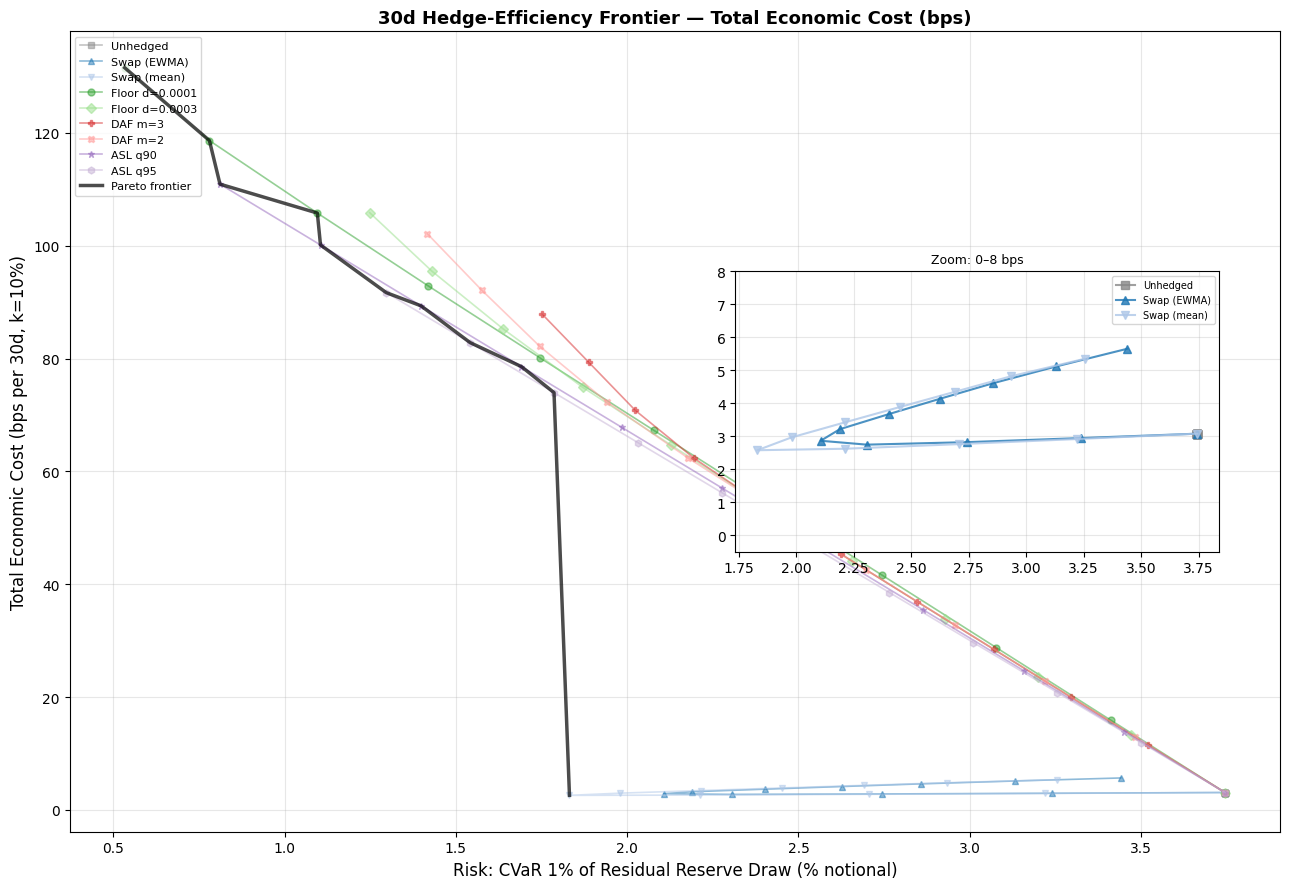

In [11]:
# C10: Total cost frontier in bps + inset
fig, ax = plt.subplots(figsize=(13, 9))
for strat in frontier_df["strategy"].unique():
    sdf = frontier_df[frontier_df["strategy"]==strat].sort_values("h")
    ax.plot(sdf["cvar_01_loss"]*100, sdf["cost_k10"]*10000,
            marker=MARKERS.get(strat,"o"), label=strat, color=COLORS.get(strat,"#333"),
            linewidth=1.2, markersize=5, alpha=0.5)

# Pareto for cost lens
all_cost = frontier_df[frontier_df["h"]>0][["strategy","h","cvar_01_loss","cost_k10"]].copy()
pc_mask = []
for idx, row in all_cost.iterrows():
    dom = False
    for idx2, row2 in all_cost.iterrows():
        if idx==idx2: continue
        if (row2["cvar_01_loss"]<=row["cvar_01_loss"] and row2["cost_k10"]<=row["cost_k10"]
            and (row2["cvar_01_loss"]<row["cvar_01_loss"] or row2["cost_k10"]<row["cost_k10"])):
            dom=True; break
    pc_mask.append(not dom)
all_cost["pareto"] = pc_mask
pp_cost = all_cost[all_cost["pareto"]].sort_values("cvar_01_loss")
ax.plot(pp_cost["cvar_01_loss"]*100, pp_cost["cost_k10"]*10000, "k-", linewidth=2.5, alpha=0.7, zorder=8, label="Pareto frontier")

ax.set_xlabel("Risk: CVaR 1% of Residual Reserve Draw (% notional)", fontsize=12)
ax.set_ylabel("Total Economic Cost (bps per 30d, k=10%)", fontsize=12)
ax.set_title("30d Hedge-Efficiency Frontier — Total Economic Cost (bps)", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)

# Inset zoom for 0-10 bps region
axins = ax.inset_axes([0.55, 0.35, 0.4, 0.35])
for strat in ["Unhedged","Swap (EWMA)","Swap (mean)"]:
    sdf = frontier_df[frontier_df["strategy"]==strat].sort_values("h")
    axins.plot(sdf["cvar_01_loss"]*100, sdf["cost_k10"]*10000,
               marker=MARKERS.get(strat,"o"), color=COLORS.get(strat,"#333"),
               linewidth=1.5, markersize=6, alpha=0.8, label=strat)
axins.set_ylim(-0.5, 8); axins.set_title("Zoom: 0–8 bps", fontsize=9)
axins.legend(fontsize=7); axins.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/frontier_30d_total_cost_bps.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

### 5c. Capital-Locked Frontier (Stock of Capital Required)

y-axis = $R_\alpha + M_\alpha$ (% of notional) — the **stock** of capital that must be locked, not the flow cost. This is where swaps stop looking free: they require ~3.4% margin, comparable to unhedged reserves (~3.7%).

Options require reserve only (no margin); their capital locked = CVaR of residual loss.

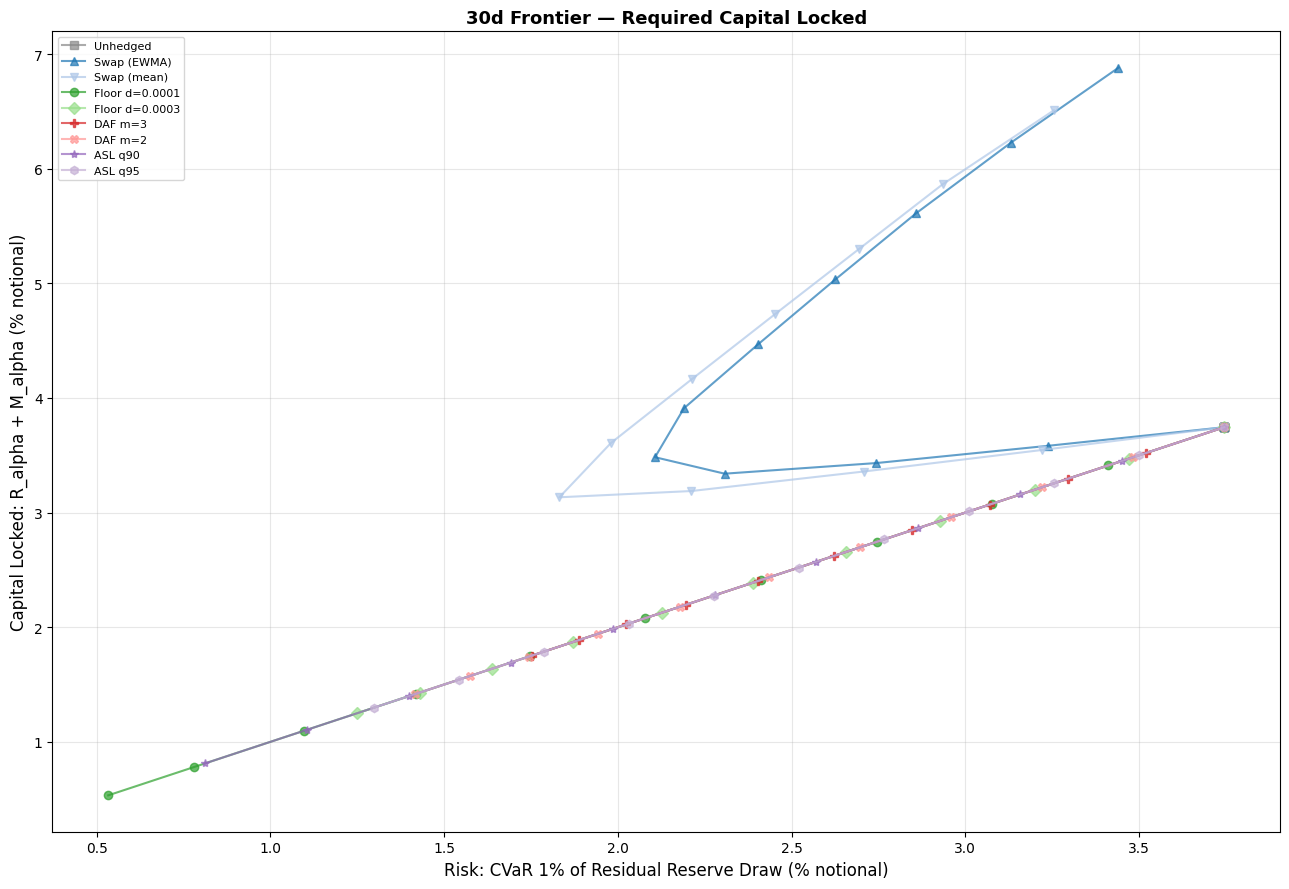

In [12]:
# B5: Capital-locked frontier (risk vs R_alpha + M_alpha)
fig, ax = plt.subplots(figsize=(13, 9))
for strat in frontier_df["strategy"].unique():
    sdf = frontier_df[frontier_df["strategy"]==strat].sort_values("h")
    capital = sdf["cvar_01_loss"] + sdf["margin"]
    ax.plot(sdf["cvar_01_loss"]*100, capital*100,
            marker=MARKERS.get(strat,"o"), label=strat, color=COLORS.get(strat,"#333"),
            linewidth=1.5, markersize=6, alpha=0.7)

ax.set_xlabel("Risk: CVaR 1% of Residual Reserve Draw (% notional)", fontsize=12)
ax.set_ylabel("Capital Locked: R_alpha + M_alpha (% notional)", fontsize=12)
ax.set_title("30d Frontier — Required Capital Locked", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper left"); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/frontier_30d_capital_locked.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

### Capital Decomposition at $h=1$

**Panel A:** Capital locked (reserve + margin, stacked). **Panel B:** Premium (cash cost). These are economically different — capital is a stock, premium is a flow — shown separately to avoid confusion.

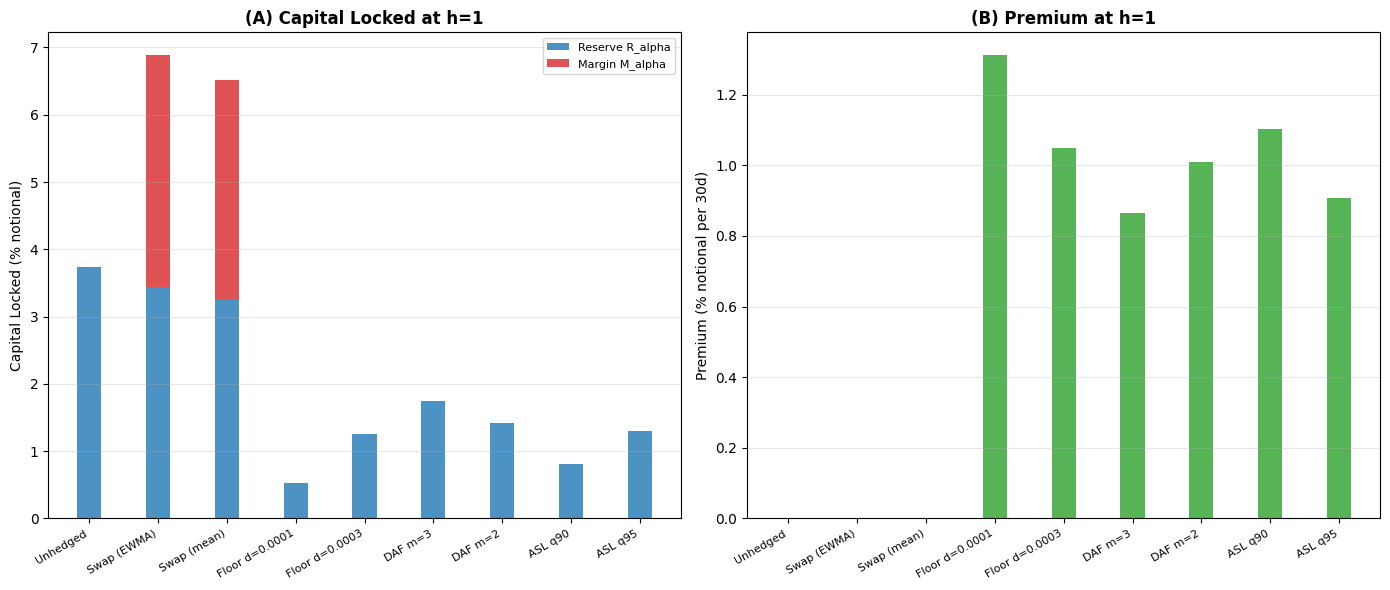

In [13]:
# C11: 2-panel capital decomposition
h1f = frontier_df[frontier_df["h"]==1.0].set_index("strategy")
strats = ["Unhedged","Swap (EWMA)","Swap (mean)","Floor d=0.0001","Floor d=0.0003","DAF m=3","DAF m=2","ASL q90","ASL q95"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(strats)); w = 0.35
# Panel A: Capital locked
reserves = [h1f.loc[s,"cvar_01_loss"]*100 for s in strats]
margins = [h1f.loc[s,"margin"]*100 for s in strats]
ax1.bar(x, reserves, w, label="Reserve R_alpha", color="#1f77b4", alpha=0.8)
ax1.bar(x, margins, w, bottom=reserves, label="Margin M_alpha", color="#d62728", alpha=0.8)
ax1.set_xticks(x); ax1.set_xticklabels(strats, rotation=30, ha="right", fontsize=8)
ax1.set_ylabel("Capital Locked (% notional)"); ax1.set_title("(A) Capital Locked at h=1", fontweight="bold")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3, axis="y")
# Panel B: Premium
prems = [h1f.loc[s,"premium"]*100 for s in strats]
ax2.bar(x, prems, w, color="#2ca02c", alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(strats, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Premium (% notional per 30d)"); ax2.set_title("(B) Premium at h=1", fontweight="bold")
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/capital_decomposition_2panel.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

### 5d. Net Cashflow Frontier

x = left-tail CVaR$_{1\%}$ of net CF (more negative = worse). y = mean net CF (higher = more carry). Options are insurance — expected net CF dropping is the cost of protection, not a bug.

The swap "hook" (non-monotonic CVaR) is explained in the diagnostic below.

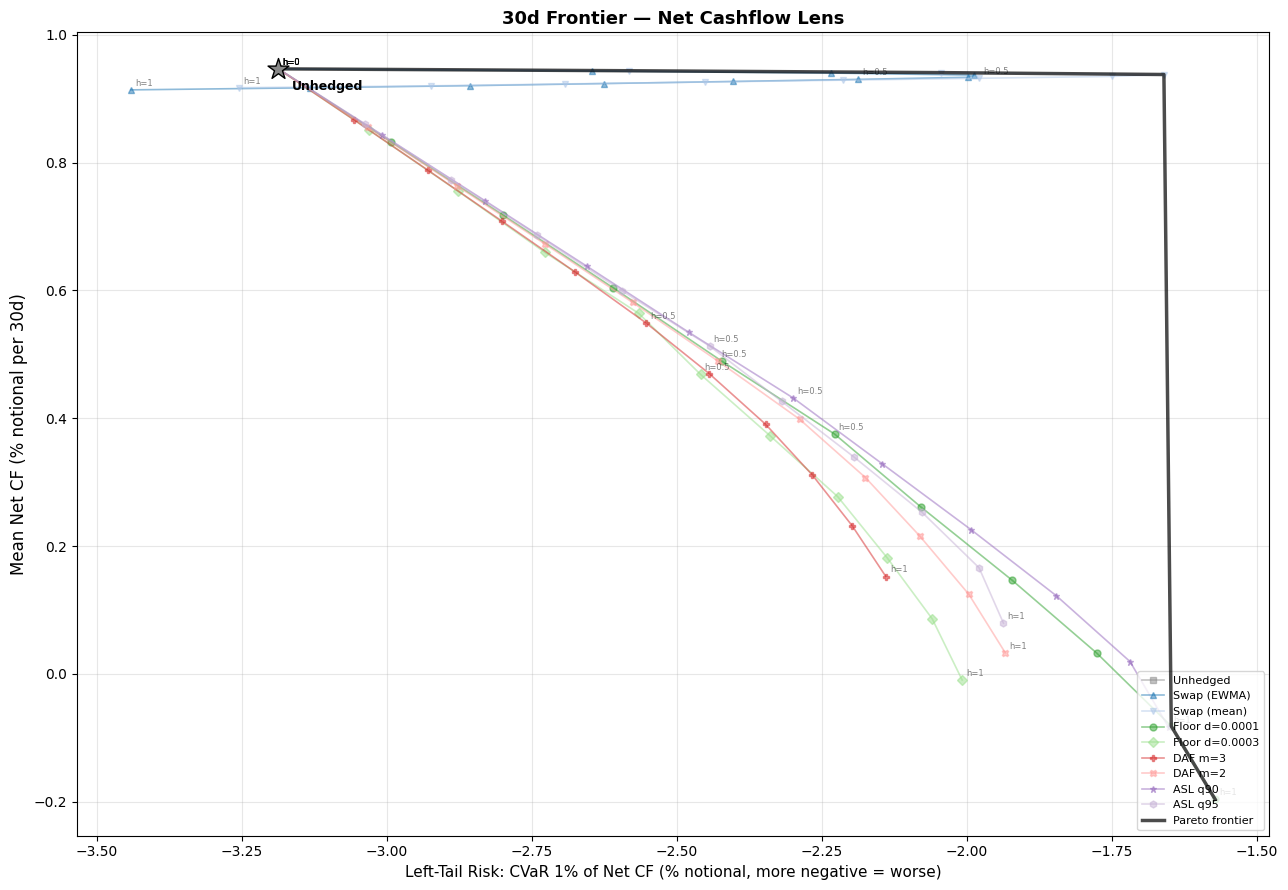

Upside retention + P(loss) at h=1:

  Unhedged            : retention=100.0%  Mean=0.947%  P(loss)=15.2%
  Swap (mean)         : retention=96.9%  Mean=0.917%  P(loss)=15.9%
  Swap (EWMA)         : retention=96.5%  Mean=0.914%  P(loss)=16.2%
  DAF m=3             : retention=16.1%  Mean=0.152%  P(loss)=68.8%
  ASL q95             : retention=8.4%  Mean=0.079%  P(loss)=71.3%
  DAF m=2             : retention=3.5%  Mean=0.033%  P(loss)=73.5%
  Floor d=0.0003      : retention=-1.0%  Mean=-0.010%  P(loss)=73.9%
  ASL q90             : retention=-8.8%  Mean=-0.084%  P(loss)=76.7%
  Floor d=0.0001      : retention=-20.7%  Mean=-0.196%  P(loss)=80.7%


In [14]:
# C14: Net-CF frontier + Pareto + h labels + P(loss)
netcf_rows = []
for h in H_GRID:
    netcf_rows.append({"strategy":"Unhedged","h":h,"mean_netcf":float(np.mean(netcf_per_window)),
        "cvar_01_netcf":cvar(netcf_per_window,ALPHA),"p_loss":prob_loss(netcf_per_window),"premium":0})
for swap_name, s_rates in [("Swap (EWMA)",swap_ewma_rates),("Swap (mean)",swap_mean_rates)]:
    for h in H_GRID:
        bl = np.array([(1-h)*float(np.sum(w))+h*float(len(w))*s_rates[idx] for idx,w in enumerate(windows_30d)])
        netcf_rows.append({"strategy":swap_name,"h":h,"mean_netcf":float(np.mean(bl)),
            "cvar_01_netcf":cvar(bl,ALPHA),"p_loss":prob_loss(bl),"premium":0})
for name in payoff_arrays:
    p = premiums[name]
    for h in H_GRID:
        hcf = netcf_per_window + h*payoff_arrays[name] - h*p
        netcf_rows.append({"strategy":name,"h":h,"mean_netcf":float(np.mean(hcf)),
            "cvar_01_netcf":cvar(hcf,ALPHA),"p_loss":prob_loss(hcf),"premium":h*p})
netcf_df = pd.DataFrame(netcf_rows)

# Pareto for net-CF (maximize mean, maximize CVaR i.e. less negative)
nc_pts = netcf_df[netcf_df["h"]>0][["strategy","h","mean_netcf","cvar_01_netcf"]].copy()
nc_pareto = []
for idx, row in nc_pts.iterrows():
    dom = False
    for idx2, row2 in nc_pts.iterrows():
        if idx==idx2: continue
        if (row2["mean_netcf"]>=row["mean_netcf"] and row2["cvar_01_netcf"]>=row["cvar_01_netcf"]
            and (row2["mean_netcf"]>row["mean_netcf"] or row2["cvar_01_netcf"]>row["cvar_01_netcf"])):
            dom=True; break
    nc_pareto.append(not dom)
nc_pts["pareto"] = nc_pareto
pp_nc = nc_pts[nc_pts["pareto"]].sort_values("cvar_01_netcf")

fig, ax = plt.subplots(figsize=(13, 9))
for strat in netcf_df["strategy"].unique():
    sdf = netcf_df[netcf_df["strategy"]==strat].sort_values("h")
    ax.plot(sdf["cvar_01_netcf"]*100, sdf["mean_netcf"]*100,
        marker=MARKERS.get(strat,"o"), label=strat, color=COLORS.get(strat,"#333"), linewidth=1.2, markersize=5, alpha=0.5)
    for hv in [0.0, 0.5, 1.0]:
        pt = sdf[sdf["h"]==hv]
        if len(pt) > 0 and strat not in ("Unhedged",):
            ax.annotate(f"h={hv:.0g}", (pt["cvar_01_netcf"].values[0]*100, pt["mean_netcf"].values[0]*100),
                        fontsize=6, alpha=0.5, xytext=(3,3), textcoords="offset points")
# Pareto
ax.plot(pp_nc["cvar_01_netcf"]*100, pp_nc["mean_netcf"]*100, "k-", linewidth=2.5, alpha=0.7, zorder=8, label="Pareto frontier")
# Unhedged star
uh = netcf_df[(netcf_df["strategy"]=="Unhedged")&(netcf_df["h"]==0)].iloc[0]
ax.scatter(uh["cvar_01_netcf"]*100, uh["mean_netcf"]*100, s=250, marker="*",
    color=COLORS["Unhedged"], zorder=10, edgecolors="black")
ax.annotate("Unhedged", (uh["cvar_01_netcf"]*100, uh["mean_netcf"]*100),
    fontsize=9, fontweight="bold", xytext=(10,-15), textcoords="offset points")

ax.set_xlabel("Left-Tail Risk: CVaR 1% of Net CF (% notional, more negative = worse)", fontsize=11)
ax.set_ylabel("Mean Net CF (% notional per 30d)", fontsize=12)
ax.set_title("30d Frontier — Net Cashflow Lens", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="lower right"); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/frontier_30d_netcf.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

# Upside retention + P(loss)
h1nc = netcf_df[netcf_df["h"]==1.0].copy()
uh_mean = h1nc[h1nc["strategy"]=="Unhedged"]["mean_netcf"].values[0]
h1nc["retention"] = h1nc["mean_netcf"]/uh_mean*100
print("Upside retention + P(loss) at h=1:\n")
for _, r in h1nc.sort_values("mean_netcf", ascending=False).iterrows():
    print(f"  {r['strategy']:20s}: retention={r['retention']:.1f}%  Mean={r['mean_netcf']*100:.3f}%  P(loss)={r['p_loss']*100:.1f}%")

### Why the swap curve "hooks" (non-monotonic CVaR)

The trailing-lookback swap rate is **correlated with funding outcomes** — when funding is bad, the trailing rate is also bad. The scatter below shows this directly. At intermediate $h$ (~0.3), the blend diversifies; at $h=1$, the swap locks in stress-era rates, producing worse CVaR than unhedged.

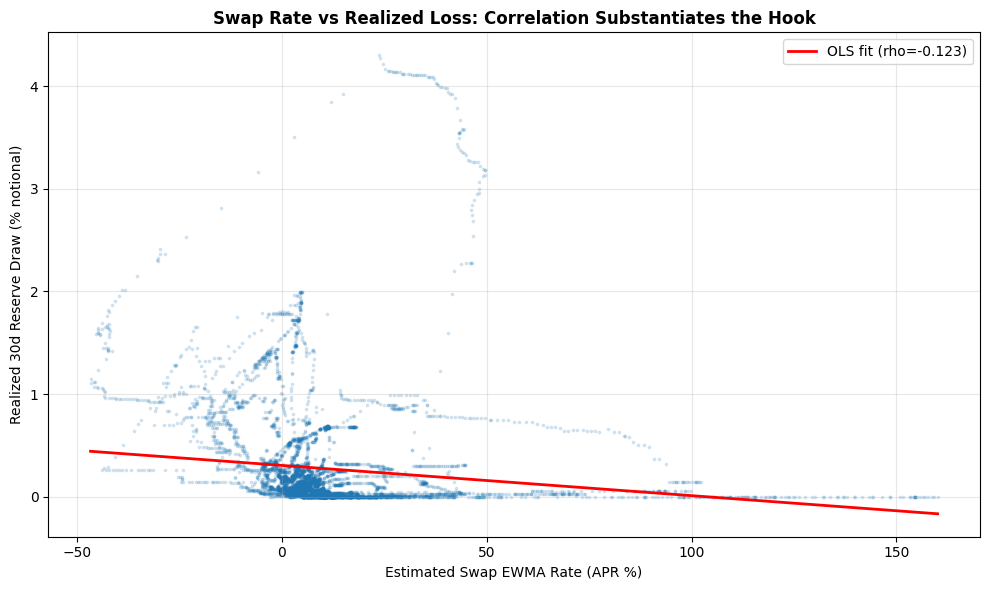

Correlation (swap EWMA rate, Lambda): rho = -0.1228


In [15]:
# B6: Swap rate vs realized Lambda scatter
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(swap_ewma_rates*INTERVALS_PER_YEAR*100, lambda_per_window*100, s=3, alpha=0.15, color="#1f77b4")
rho = np.corrcoef(swap_ewma_rates, lambda_per_window)[0,1]
z = np.polyfit(swap_ewma_rates*INTERVALS_PER_YEAR*100, lambda_per_window*100, 1)
x_fit = np.linspace(swap_ewma_rates.min()*INTERVALS_PER_YEAR*100, swap_ewma_rates.max()*INTERVALS_PER_YEAR*100, 100)
ax.plot(x_fit, np.polyval(z, x_fit), "r-", linewidth=2, label=f"OLS fit (rho={rho:.3f})")
ax.set_xlabel("Estimated Swap EWMA Rate (APR %)"); ax.set_ylabel("Realized 30d Reserve Draw (% notional)")
ax.set_title("Swap Rate vs Realized Loss: Correlation Substantiates the Hook", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/swap_rate_vs_loss.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")
print(f"Correlation (swap EWMA rate, Lambda): rho = {rho:.4f}")

## 6. Uncertainty Bands at $h=1$

Three layers quantify how much the point estimates could shift:
- **Bootstrap** (500 block-bootstrap resamples, block=90): sampling uncertainty
- **Era** (rolling 3-year sub-windows, ~20 sub-samples, **10th–90th percentile**): nonstationarity — the dominant driver
- **Model** (200 paths from Phase 6.4 semi-Markov simulator, $g=5$, $p_{\text{augment}}=0.02$): model risk

Swaps are omitted from this analysis because their premium is zero and their margin treatment differs from option products. The plot shows all three bands for each option product.

In [16]:
# Bootstrap band
print("Computing bootstrap bands (500 resamples)...")
N_BOOT = 500; rng_boot = np.random.default_rng(RNG_SEED)
boot_results = {n: {"premium":[],"cvar":[]} for n in payoff_arrays}
for b in range(N_BOOT):
    bcf = circular_block_bootstrap(funding_cf, block_size=HORIZON_30D, n_samples=1, rng=rng_boot)[0]
    breg = np.ones(len(bcf), dtype=bool)
    bwins, _ = rolling_windows_regular(bcf, breg, HORIZON_30D)
    if len(bwins) < 50: continue
    blam = np.array([total_loss(w) for w in bwins])
    for name in payoff_arrays:
        if "Floor" in name:
            d = 0.0001 if "0.0001" in name else 0.0003
            bp = np.array([vanilla_floor(w, deductible=d) for w in bwins])
        elif "DAF" in name:
            m = 3 if "m=3" in name else 2
            bp = np.array([distress_activated_floor(w, threshold_b=0.0001, streak_m=m, deductible=0.0001) for w in bwins])
        else:
            d = ASL_D_30D_Q90 if "q90" in name else ASL_D_30D_Q95
            bp = np.array([aggregate_stop_loss(w, deductible_D=d) for w in bwins])
        boot_results[name]["premium"].append(full_premium(bp)["total"])
        boot_results[name]["cvar"].append(reserve_requirement(np.maximum(0.0, blam - bp), alpha=ALPHA))
print("Bootstrap done.")

Computing bootstrap bands (500 resamples)...


Bootstrap done.


In [17]:
# Era band (p10-p90)
print("Computing era bands...")
ERA_WINDOW = 3*365*3; ERA_STEP = 180
era_starts = list(range(0, n_total - ERA_WINDOW - HORIZON_30D, ERA_STEP))
era_results = {n: {"premium":[],"cvar":[]} for n in payoff_arrays}
for s in era_starts:
    ecf = funding_cf[s:s+ERA_WINDOW]; ereg = is_regular[s:s+ERA_WINDOW]
    ewins, _ = rolling_windows_regular(ecf, ereg, HORIZON_30D)
    if len(ewins) < 50: continue
    elam = np.array([total_loss(w) for w in ewins])
    for name in payoff_arrays:
        if "Floor" in name:
            d = 0.0001 if "0.0001" in name else 0.0003
            ep = np.array([vanilla_floor(w, deductible=d) for w in ewins])
        elif "DAF" in name:
            m = 3 if "m=3" in name else 2
            ep = np.array([distress_activated_floor(w, threshold_b=0.0001, streak_m=m, deductible=0.0001) for w in ewins])
        else:
            d = ASL_D_30D_Q90 if "q90" in name else ASL_D_30D_Q95
            ep = np.array([aggregate_stop_loss(w, deductible_D=d) for w in ewins])
        era_results[name]["premium"].append(full_premium(ep)["total"])
        era_results[name]["cvar"].append(reserve_requirement(np.maximum(0.0, elam - ep), alpha=ALPHA))
print("Era bands done.")

Computing era bands...


Era bands done.


In [18]:
# Model scenario band
print("Computing model scenario bands (200 paths)...")
ep_data = extract_episodes_and_clusters(funding_cf, threshold_b=0.0001, gap_g=5)
tail_fit = fit_cluster_tail(ep_data["clusters"], quantile_threshold=0.90)
tp = tail_fit if tail_fit.get("fit_success", False) else None
sim_paths = simulate_semi_markov(ep_data["clusters"], ep_data["calm_segments"],
    n_intervals=10_000, n_paths=200, rng=np.random.default_rng(123), tail_params=tp, p_augment=0.02, cap=CAP)
model_results = {n: {"premium":[],"cvar":[]} for n in payoff_arrays}
for pidx in range(sim_paths.shape[0]):
    path = sim_paths[pidx]; preg = np.ones(len(path), dtype=bool)
    pwins, _ = rolling_windows_regular(path, preg, HORIZON_30D)
    if len(pwins) < 50: continue
    plam = np.array([total_loss(w) for w in pwins])
    for name in payoff_arrays:
        if "Floor" in name:
            d = 0.0001 if "0.0001" in name else 0.0003
            pp = np.array([vanilla_floor(w, deductible=d) for w in pwins])
        elif "DAF" in name:
            m = 3 if "m=3" in name else 2
            pp = np.array([distress_activated_floor(w, threshold_b=0.0001, streak_m=m, deductible=0.0001) for w in pwins])
        else:
            d = ASL_D_30D_Q90 if "q90" in name else ASL_D_30D_Q95
            pp = np.array([aggregate_stop_loss(w, deductible_D=d) for w in pwins])
        model_results[name]["premium"].append(full_premium(pp)["total"])
        model_results[name]["cvar"].append(reserve_requirement(np.maximum(0.0, plam - pp), alpha=ALPHA))
print("Model bands done.")

Computing model scenario bands (200 paths)...


Model bands done.


      Strategy Prem pt  Boot [5,95] Era [p10,p90] CVaR pt    CVaR Boot     CVaR Era   CVaR Model
Floor d=0.0001   1.311 [0.59, 1.50]  [0.57, 1.47]   0.533 [0.41, 0.56] [0.46, 0.55] [0.47, 0.57]
Floor d=0.0003   1.048 [0.45, 1.17]  [0.31, 1.14]   1.248 [0.95, 1.41] [1.13, 1.29] [1.10, 1.44]
       DAF m=3   0.864 [0.31, 0.97]  [0.40, 0.95]   1.752 [1.02, 1.88] [0.91, 1.77] [1.15, 2.02]
       DAF m=2   1.010 [0.39, 1.15]  [0.50, 1.13]   1.416 [0.86, 1.61] [0.65, 1.30] [0.98, 1.51]
       ASL q90   1.102 [0.32, 1.29]  [0.41, 1.28]   0.811 [0.81, 0.81] [0.81, 0.81] [0.81, 0.81]
       ASL q95   0.906 [0.14, 1.09]  [0.23, 1.07]   1.297 [1.30, 1.30] [1.30, 1.30] [1.30, 1.30]


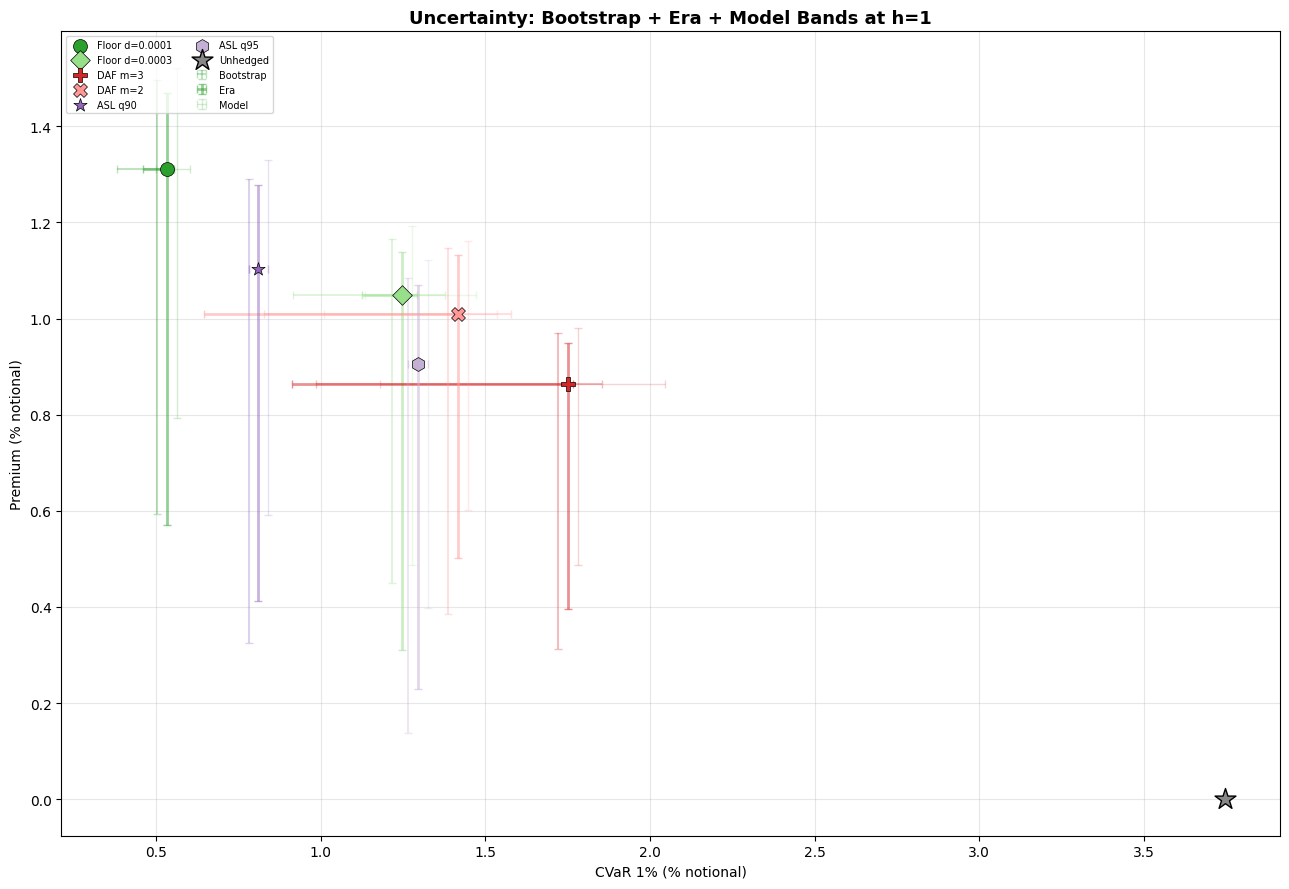

In [19]:
# Uncertainty summary table + all-3-bands error-bar plot
unc_rows = []
for name in payoff_arrays:
    h1r = frontier_df[(frontier_df["strategy"]==name)&(frontier_df["h"]==1.0)].iloc[0]
    bp = np.array(boot_results[name]["premium"]); bc = np.array(boot_results[name]["cvar"])
    ep = np.array(era_results[name]["premium"]); ec = np.array(era_results[name]["cvar"])
    mp = np.array(model_results[name]["premium"]); mc = np.array(model_results[name]["cvar"])
    unc_rows.append({"Strategy":name, "Prem pt":f"{h1r['premium']*100:.3f}",
        "Boot [5,95]":f"[{np.quantile(bp,0.05)*100:.2f}, {np.quantile(bp,0.95)*100:.2f}]",
        "Era [p10,p90]":f"[{np.quantile(ep,0.10)*100:.2f}, {np.quantile(ep,0.90)*100:.2f}]",
        "CVaR pt":f"{h1r['cvar_01_loss']*100:.3f}",
        "CVaR Boot":f"[{np.quantile(bc,0.05)*100:.2f}, {np.quantile(bc,0.95)*100:.2f}]",
        "CVaR Era":f"[{np.quantile(ec,0.10)*100:.2f}, {np.quantile(ec,0.90)*100:.2f}]",
        "CVaR Model":f"[{np.quantile(mc,0.05)*100:.2f}, {np.quantile(mc,0.95)*100:.2f}]"})
print(pd.DataFrame(unc_rows).to_string(index=False))

# All-3-bands error-bar plot
fig, ax = plt.subplots(figsize=(13, 9))
offsets = {"bootstrap": -0.03, "era": 0.0, "model": 0.03}
band_labels_done = set()
for name in payoff_arrays:
    h1r = frontier_df[(frontier_df["strategy"]==name)&(frontier_df["h"]==1.0)].iloc[0]
    xp, yp = h1r["cvar_01_loss"]*100, h1r["premium"]*100
    ax.scatter(xp, yp, s=100, marker=MARKERS.get(name,"o"), color=COLORS.get(name,"#333"), zorder=5, label=name, edgecolors="black", linewidth=0.5)
    for band_name, data_c, data_p, q_lo, q_hi, alpha_val, lw, ls in [
        ("bootstrap", boot_results[name]["cvar"], boot_results[name]["premium"], 0.05, 0.95, 0.3, 1.5, "-"),
        ("era", era_results[name]["cvar"], era_results[name]["premium"], 0.10, 0.90, 0.5, 2, "--"),
        ("model", model_results[name]["cvar"], model_results[name]["premium"], 0.05, 0.95, 0.2, 1, ":")]:
        dc = np.array(data_c); dp = np.array(data_p)
        lbl = band_name.capitalize() if band_name not in band_labels_done else None
        band_labels_done.add(band_name)
        ax.errorbar(xp + offsets[band_name], yp,
            xerr=[[max(0, xp-np.quantile(dc,q_lo)*100)],[max(0, np.quantile(dc,q_hi)*100-xp)]],
            yerr=[[max(0, yp-np.quantile(dp,q_lo)*100)],[max(0, np.quantile(dp,q_hi)*100-yp)]],
            fmt="none", color=COLORS.get(name,"#333"), alpha=alpha_val, capsize=3, linewidth=lw, linestyle=ls, label=lbl)
ax.scatter(R_unhedged*100, 0, s=250, marker="*", color=COLORS["Unhedged"], zorder=10, edgecolors="black", label="Unhedged")
ax.set_xlabel("CVaR 1% (% notional)"); ax.set_ylabel("Premium (% notional)")
ax.set_title("Uncertainty: Bootstrap + Era + Model Bands at h=1", fontsize=13, fontweight="bold")
ax.legend(fontsize=7, loc="upper left", ncol=2); ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/frontier_30d_uncertainty_3band.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

## 7. Walk-Forward Evaluation (Deployment Realism)

Monthly walk-forward: trailing 3 years $\to$ price $\to$ apply to next 30d. **4 panels:** residual loss, premium, net CF, and **cumulative net CF** (readers understand cumulative P&L quickly).

Start/end dates and calendar x-axis are shown for interpretability.

In [20]:
from ddx.backtest.walkforward import walkforward_evaluate
wf_strategies = [
    {"name":"Unhedged","type":"unhedged"},
    {"name":"Swap (EWMA)","type":"swap","swap_method":"ewma","swap_lookback":90,"swap_halflife":45},
    {"name":"Swap (mean)","type":"swap","swap_method":"mean","swap_lookback":90},
    {"name":"Floor d=0.0001","type":"option","payoff_fn":vanilla_floor,"payoff_kwargs":{"deductible":0.0001}},
    {"name":"DAF m=3","type":"option","payoff_fn":distress_activated_floor,
     "payoff_kwargs":{"threshold_b":0.0001,"streak_m":3,"deductible":0.0001}},
    {"name":"ASL q90","type":"option","payoff_fn":aggregate_stop_loss,
     "payoff_kwargs":{"deductible_D":"calibrate"},"asl_quantile":0.90},
    {"name":"ASL q95","type":"option","payoff_fn":aggregate_stop_loss,
     "payoff_kwargs":{"deductible_D":"calibrate"},"asl_quantile":0.95},
]
print("Running walk-forward...")
wf_df = walkforward_evaluate(funding_cf, is_regular, wf_strategies,
    horizon_intervals=HORIZON_30D, train_years=3.0, step_intervals=HORIZON_30D,
    rng=np.random.default_rng(RNG_SEED))
wf_df["residual_loss"] = wf_df.apply(
    lambda r: max(0.0, r["reserve_draw_unhedged"] - r["payoff"]) if r["strategy"] not in ("Swap (EWMA)","Swap (mean)","Unhedged")
    else r["reserve_draw_hedged"], axis=1)
# Add calendar dates (C17)
intervals_per_year = int(365*24/8)
wf_df["date"] = wf_df["t_start"].apply(lambda t: timestamps.iloc[min(t, n_total-1)])
start_date = wf_df["date"].min(); end_date = wf_df["date"].max()
print(f"Walk-forward: {len(wf_df)} records, {wf_df['month_idx'].nunique()} months, {start_date.date()} to {end_date.date()}")
wf_df.to_csv(str(REPO_ROOT/"reports/tables/walkforward_pnl.csv"), index=False)

Running walk-forward...


Walk-forward: 364 records, 52 months, 2021-11-15 to 2026-01-23


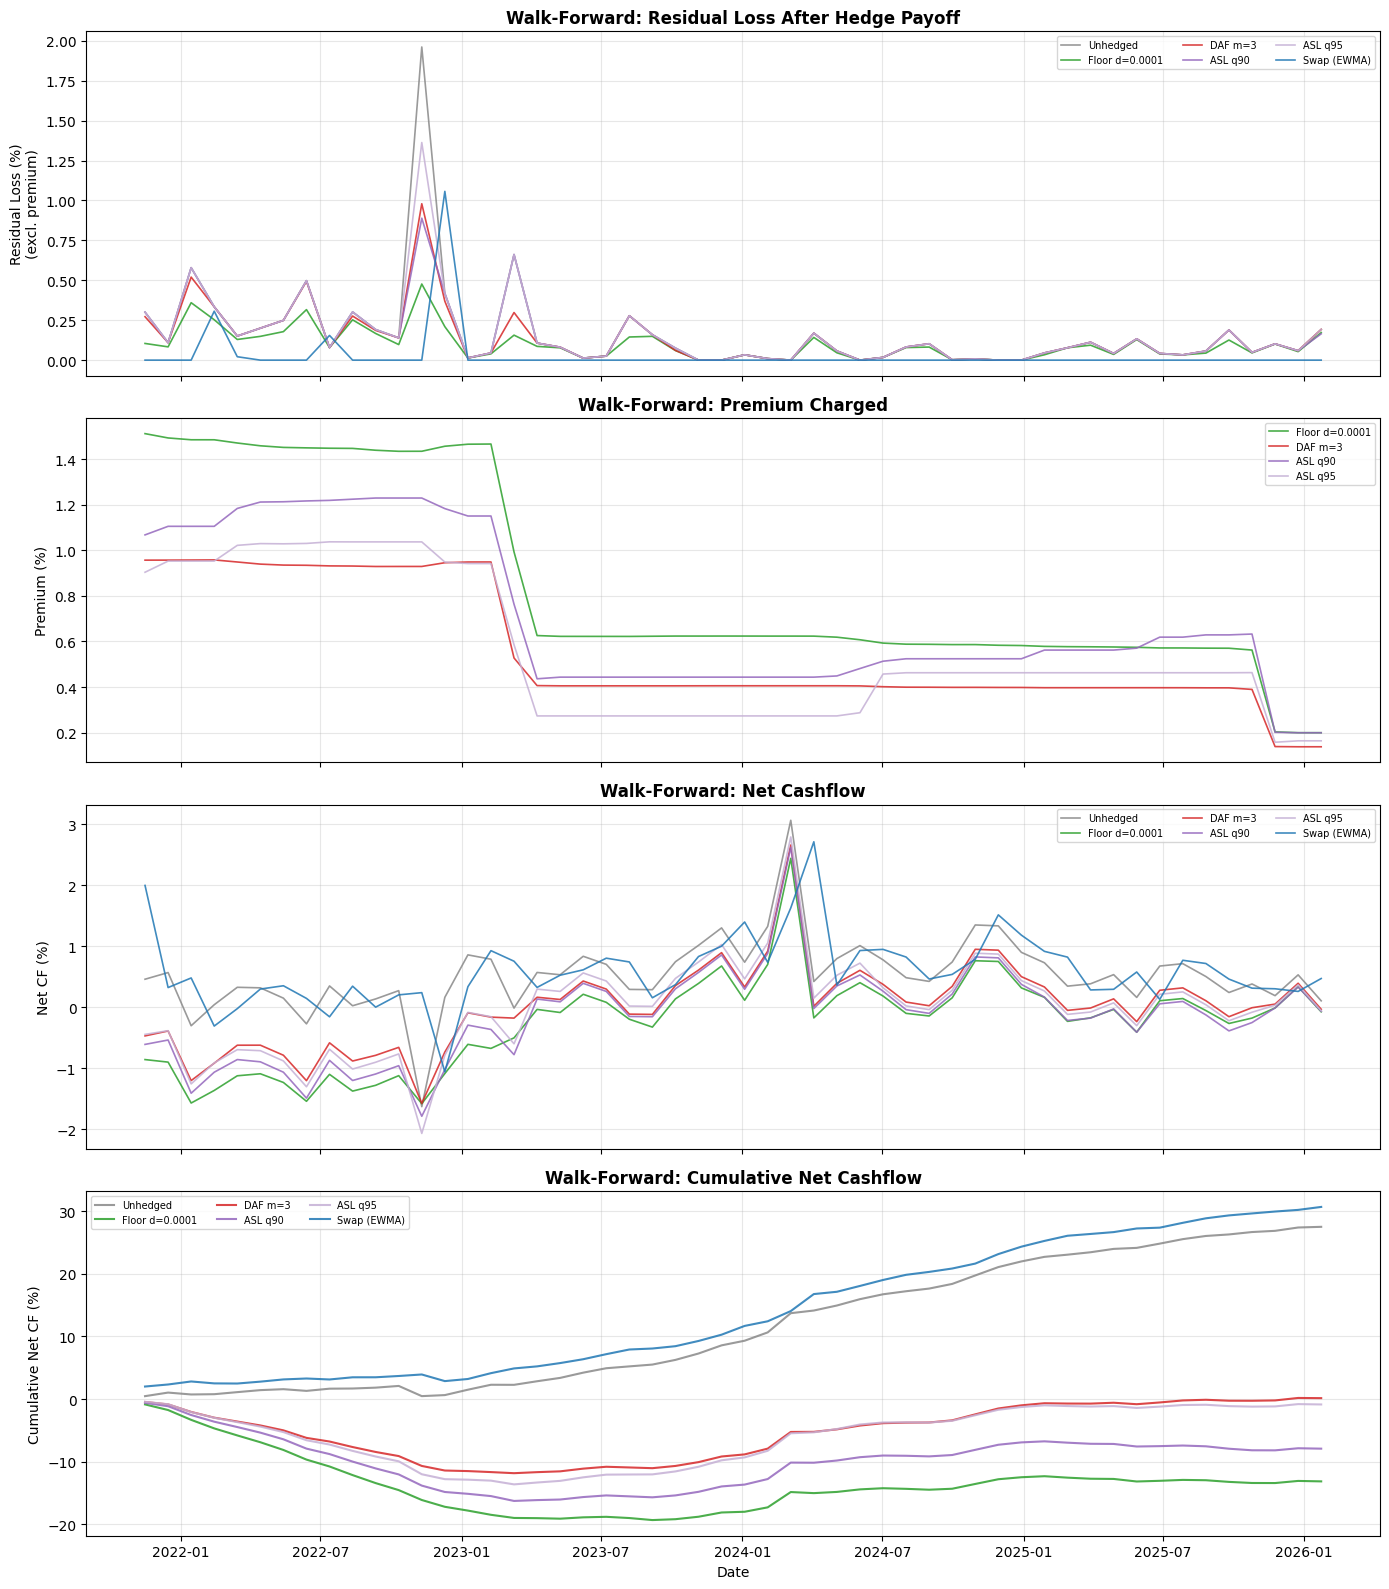


=== Walk-Forward Summary ===

                Mean Resid (%)  Max Resid (%)  Mean Prem (%)  Mean NetCF (%)
strategy                                                                    
ASL q90                 0.1439         0.8891         0.7018         -0.1522
ASL q95                 0.1536         1.3631         0.5565         -0.0166
DAF m=3                 0.1356         0.9796         0.5551          0.0028
Floor d=0.0001          0.0966         0.4768         0.8495         -0.2526
Swap (EWMA)             0.0296         1.0572         0.0000          0.5894
Swap (mean)             0.0425         1.6269         0.0000          0.5672
Unhedged                0.1651         1.9617         0.0000          0.5284


In [21]:
# C16 + B10: 4-panel walk-forward with dates + cumulative CF
plot_strats = ["Unhedged","Floor d=0.0001","DAF m=3","ASL q90","ASL q95","Swap (EWMA)"]
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

ax = axes[0]
for strat in plot_strats:
    sdf = wf_df[wf_df["strategy"]==strat].sort_values("date")
    ax.plot(sdf["date"], sdf["residual_loss"]*100, label=strat, color=COLORS.get(strat,"#333"), linewidth=1.2, alpha=0.85)
ax.set_ylabel("Residual Loss (%)\n(excl. premium)"); ax.set_title("Walk-Forward: Residual Loss After Hedge Payoff", fontweight="bold")
ax.legend(fontsize=7, ncol=3); ax.grid(True, alpha=0.3)

ax = axes[1]
for strat in [s for s in plot_strats if s not in ("Unhedged","Swap (EWMA)")]:
    sdf = wf_df[wf_df["strategy"]==strat].sort_values("date")
    ax.plot(sdf["date"], sdf["premium"]*100, label=strat, color=COLORS.get(strat,"#333"), linewidth=1.2, alpha=0.85)
ax.set_ylabel("Premium (%)"); ax.set_title("Walk-Forward: Premium Charged", fontweight="bold"); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax = axes[2]
for strat in plot_strats:
    sdf = wf_df[wf_df["strategy"]==strat].sort_values("date")
    ax.plot(sdf["date"], sdf["net_cf"]*100, label=strat, color=COLORS.get(strat,"#333"), linewidth=1.2, alpha=0.85)
ax.set_ylabel("Net CF (%)"); ax.set_title("Walk-Forward: Net Cashflow", fontweight="bold"); ax.legend(fontsize=7, ncol=3); ax.grid(True, alpha=0.3)

ax = axes[3]
for strat in plot_strats:
    sdf = wf_df[wf_df["strategy"]==strat].sort_values("date")
    ax.plot(sdf["date"], sdf["net_cf"].cumsum()*100, label=strat, color=COLORS.get(strat,"#333"), linewidth=1.5, alpha=0.85)
ax.set_ylabel("Cumulative Net CF (%)"); ax.set_xlabel("Date")
ax.set_title("Walk-Forward: Cumulative Net Cashflow", fontweight="bold"); ax.legend(fontsize=7, ncol=3); ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/walkforward_4panel.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

print("\n=== Walk-Forward Summary ===\n")
wf_sum = wf_df.groupby("strategy").agg(mean_resid=("residual_loss","mean"),max_resid=("residual_loss","max"),
    mean_prem=("premium","mean"),mean_netcf=("net_cf","mean")).round(6)
for c in wf_sum.columns: wf_sum[c+"_pct"] = wf_sum[c]*100
print(wf_sum[["mean_resid_pct","max_resid_pct","mean_prem_pct","mean_netcf_pct"]].rename(
    columns={"mean_resid_pct":"Mean Resid (%)","max_resid_pct":"Max Resid (%)","mean_prem_pct":"Mean Prem (%)","mean_netcf_pct":"Mean NetCF (%)"}).to_string())

## 8. Decision Rule: Which Hedge for Which Risk Target?

**Objective:** Minimize total economic cost $\text{Cost}_B$ at $k=10\%$.  
**Constraint:** CVaR of residual reserve draw $\leq$ target.  
**Grid:** $h \in \{0.00, 0.01, 0.02, \ldots, 1.00\}$ (101 values via interpolation from the 0.1 grid).

The **decision curve** shows the minimum-cost strategy for each risk tolerance. The table adds mean net CF and CVaR net CF for the chosen point.

**Capital netting sensitivity:** Net benefit is shown under both **additive** ($K = R + M$) and **max-netted** ($K = \max(R, M)$) assumptions.

=== Choice Map: Minimum-Cost Strategy by Risk Target ===

 Target CVaR (%)       Strategy     h Premium (%)  CVaR (%)  Cost (bps)
            0.50   (infeasible)                                        
            0.75 Floor d=0.0001  0.92    1.206158  0.730981  121.216559
            1.00        ASL q90  0.94    1.036239   0.98741  104.435429
            1.50        ASL q95  0.92     0.83362  1.492556   84.588787
            2.00    Swap (mean)   0.4         0.0  1.831473    2.575448
            2.50    Swap (mean)   0.4         0.0  1.831473    2.575448
            3.00    Swap (mean)   0.4         0.0  1.831473    2.575448
            3.50    Swap (mean)   0.4         0.0  1.831473    2.575448


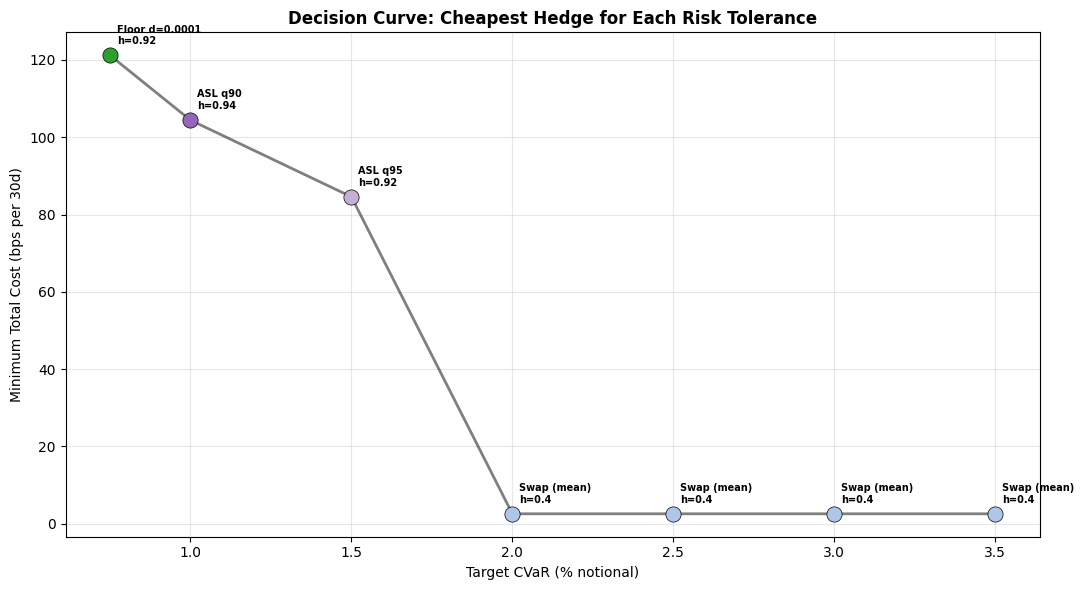

In [22]:
# B7 + C22 + E4: Decision curve + expanded choice map (fine h grid via interpolation)
from scipy.interpolate import interp1d

# Build fine-grid frontier for each strategy via linear interpolation
fine_h = np.arange(0, 1.005, 0.01)
fine_rows = []
for strat in frontier_df["strategy"].unique():
    sdf = frontier_df[frontier_df["strategy"]==strat].sort_values("h")
    if len(sdf) < 2: continue
    for col in ["cvar_01_loss","premium","cost_k10","margin","mean_loss"]:
        f_interp = interp1d(sdf["h"], sdf[col], kind="linear", fill_value="extrapolate")
        for h in fine_h:
            if h == 0 and strat != "Unhedged": continue
            existing = [r for r in fine_rows if r["strategy"]==strat and r["h"]==round(h,2)]
            if existing:
                existing[0][col] = float(f_interp(h))
            else:
                fine_rows.append({"strategy":strat,"h":round(h,2),col:float(f_interp(h))})

fine_df = pd.DataFrame(fine_rows).dropna()

# Choice map for multiple CVaR targets
targets = [0.005, 0.0075, 0.010, 0.015, 0.020, 0.025, 0.030, 0.035]
choice_rows = []
for t in targets:
    feasible = fine_df[fine_df["cvar_01_loss"] <= t]
    if len(feasible) > 0:
        best = feasible.loc[feasible["cost_k10"].idxmin()]
        choice_rows.append({"Target CVaR (%)":t*100,"Strategy":best["strategy"],"h":best["h"],
            "Premium (%)":best.get("premium",0)*100,"CVaR (%)":best["cvar_01_loss"]*100,
            "Cost (bps)":best["cost_k10"]*10000})
    else:
        choice_rows.append({"Target CVaR (%)":t*100,"Strategy":"(infeasible)","h":"","Premium (%)":"","CVaR (%)":"","Cost (bps)":""})

choice_df = pd.DataFrame(choice_rows)
print("=== Choice Map: Minimum-Cost Strategy by Risk Target ===\n")
print(choice_df.to_string(index=False))

# B7: Decision curve plot
fig, ax = plt.subplots(figsize=(11, 6))
valid = [r for r in choice_rows if r["Strategy"] != "(infeasible)"]
if valid:
    xs = [r["Target CVaR (%)"] for r in valid]
    ys = [r["Cost (bps)"] for r in valid]
    labels = [f'{r["Strategy"]}\nh={r["h"]}' for r in valid]
    colors_map = [COLORS.get(r["Strategy"], "#333") for r in valid]
    ax.plot(xs, ys, "k-", linewidth=2, alpha=0.5)
    for x, y, lbl, c in zip(xs, ys, labels, colors_map):
        ax.scatter(x, y, s=120, color=c, zorder=5, edgecolors="black", linewidth=0.5)
        ax.annotate(lbl, (x, y), fontsize=7, fontweight="bold", xytext=(5,8), textcoords="offset points")
ax.set_xlabel("Target CVaR (% notional)"); ax.set_ylabel("Minimum Total Cost (bps per 30d)")
ax.set_title("Decision Curve: Cheapest Hedge for Each Risk Tolerance", fontweight="bold")
ax.grid(True, alpha=0.3); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/decision_curve.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

### Capital Efficiency: Additive vs Max-Netted Margin

The ranking can depend on whether swap margin and reserve are **additive** (separate pools, conservative) or **max-netted** (shared pool). Both are shown.

In [23]:
# B9 + C18: Capital efficiency table with both aggregation assumptions
h1t = frontier_df[frontier_df["h"]==1.0].copy()
cap_rows = []
for _, r in h1t.iterrows():
    R = r["cvar_01_loss"]; M = r["margin"]; P = r["premium"]
    K_add = R + M; K_max = max(R, M)
    nb_add = 0.10*(30/365)*(R_unhedged - K_add) - P
    nb_max = 0.10*(30/365)*(R_unhedged - K_max) - P
    k_star_add = P / ((30/365)*(R_unhedged - K_add)) if P > 0 and (R_unhedged - K_add) > 0 else np.nan
    cap_rows.append({"Strategy":r["strategy"],"Premium (%)":P*100,"Reserve (%)":R*100,"Margin (%)":M*100,
        "K_add (%)":K_add*100,"K_max (%)":K_max*100,
        "Cost_add (bps)":(total_economic_cost(P, R+M, 0.10, 30))*10000,
        "NB_add (bps)":nb_add*10000, "NB_max (bps)":nb_max*10000,
        "k* (add)":f"{k_star_add*100:.0f}%" if not np.isnan(k_star_add) else "n/a"})
cap_df = pd.DataFrame(cap_rows)
print(cap_df.to_string(index=False, float_format="%.2f"))
cap_df.to_csv(str(REPO_ROOT/"reports/tables/capital_efficiency_30d.csv"), index=False)

      Strategy  Premium (%)  Reserve (%)  Margin (%)  K_add (%)  K_max (%)  Cost_add (bps)  NB_add (bps)  NB_max (bps) k* (add)
      Unhedged         0.00         3.74        0.00       3.74       3.74            3.08          0.00          0.00      n/a
   Swap (EWMA)         0.00         3.44        3.44       6.88       3.44            5.66         -2.58          0.25      n/a
   Swap (mean)         0.00         3.25        3.25       6.51       3.25            5.35         -2.27          0.40      n/a
Floor d=0.0001         1.31         0.53        0.00       0.53       0.53          131.54       -128.46       -128.46     497%
Floor d=0.0003         1.05         1.25        0.00       1.25       1.25          105.85       -102.77       -102.77     511%
       DAF m=3         0.86         1.75        0.00       1.75       1.75           87.85        -84.77        -84.77     528%
       DAF m=2         1.01         1.42        0.00       1.42       1.42          102.12        -99.04

## 9. Robustness and Sensitivity

### 9a. Sharpness Stability (Rank Plot)

ASL q95 ranks **#1** across all pricing functionals. The rank plot (not raw values) prevents misinterpreting magnitude differences across functionals.

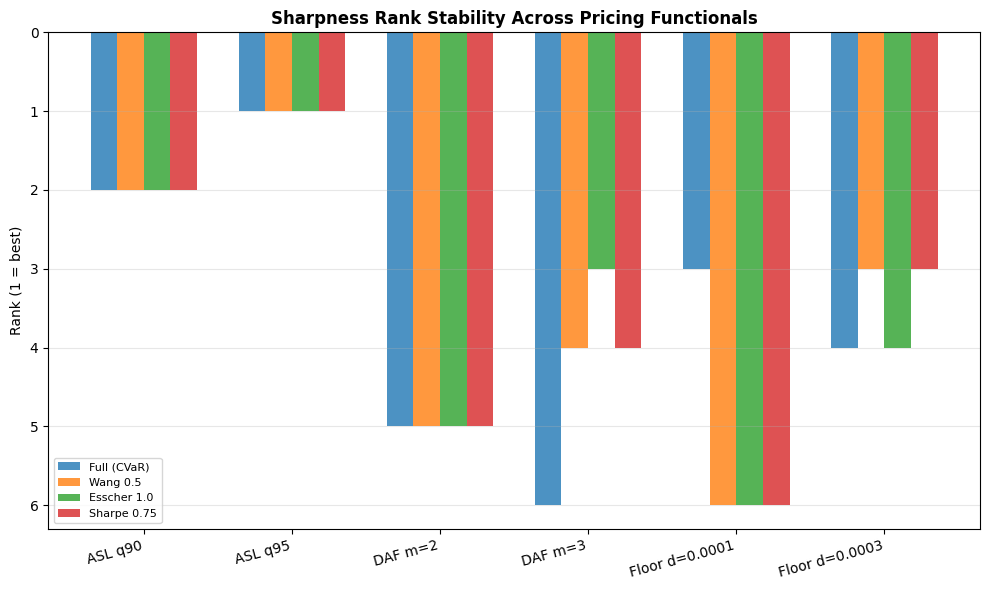

Rank table (1=best):
Method          Esscher 1.0  Full (CVaR)  Sharpe 0.75  Wang 0.5
Strategy                                                       
ASL q90                   2            2            2         2
ASL q95                   1            1            1         1
DAF m=2                   5            5            5         5
DAF m=3                   3            6            4         4
Floor d=0.0001            6            3            6         6
Floor d=0.0003            4            4            3         3


In [24]:
# C19: Sharpness rank plot
methods = ["full","wang","esscher","target_sharpe"]
mlabels = {"full":"Full (CVaR)","wang":"Wang 0.5","esscher":"Esscher 1.0","target_sharpe":"Sharpe 0.75"}
func_rows = []
for name, payoffs in payoff_arrays.items():
    for m in methods:
        res = compute_premium(payoffs, method=m)
        prem = res.get("premium", res.get("total", 0.0))
        resid = np.maximum(0.0, lambda_per_window - payoffs)
        r_h = reserve_requirement(resid, alpha=ALPHA)
        func_rows.append({"Strategy":name,"Method":mlabels[m],"Sharpness":(R_unhedged-r_h)/prem if prem>0 else 0})
func_df = pd.DataFrame(func_rows)
rank_df = func_df.pivot_table(index="Strategy",columns="Method",values="Sharpness").rank(ascending=False).astype(int)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(rank_df.index)); width = 0.18
for i, m in enumerate(mlabels.values()):
    if m in rank_df.columns:
        ax.bar(x + i*width, rank_df[m].values, width, label=m, alpha=0.8)
ax.set_xticks(x + 1.5*width); ax.set_xticklabels(rank_df.index, rotation=15, ha="right")
ax.set_ylabel("Rank (1 = best)"); ax.set_title("Sharpness Rank Stability Across Pricing Functionals", fontweight="bold")
ax.invert_yaxis(); ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y"); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/sharpness_ranks.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")
print("Rank table (1=best):"); print(rank_df.to_string())

### 9b. Cost-of-Capital Sensitivity + Break-Even $k^*$

The table extends to $k=700\%$ to show where options become cheaper than reserves. The bar chart shows $k^*$ per strategy.

k (%)              10    100     20    200    300     50    500    700
Strategy                                                              
ASL q90         110.9  116.9  111.6  123.6  130.2  113.6  143.6  156.9
ASL q95          91.7  101.3   92.7  111.9  122.6   95.9  143.9  165.2
DAF m=3          87.9  100.8   89.3  115.2  129.6   93.6  158.4  187.2
Floor d=0.0001  131.5  135.5  132.0  139.9  144.2  133.3  153.0  161.8
Swap (EWMA)       5.7   56.6   11.3  113.1  169.7   28.3  282.8  395.9
Unhedged          3.1   30.8    6.2   61.6   92.3   15.4  153.9  215.5


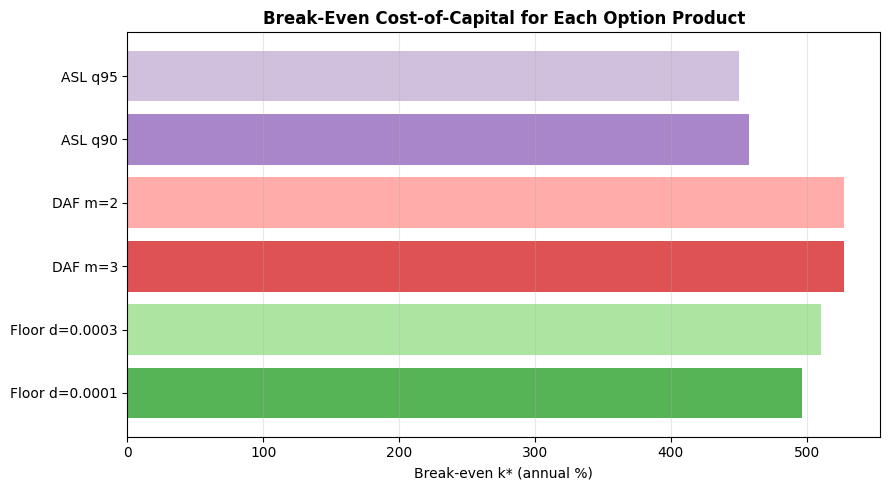

In [25]:
# C20: Extended k grid + B8: break-even bar
k_vals = [0.10, 0.20, 0.50, 1.00, 2.00, 3.00, 5.00, 7.00]
coc_rows = []
for name in ["Unhedged","Floor d=0.0001","DAF m=3","ASL q90","ASL q95","Swap (EWMA)"]:
    h1r = frontier_df[(frontier_df["strategy"]==name)&(frontier_df["h"]==1.0)]
    if len(h1r)==0: continue
    r = h1r.iloc[0]
    for k in k_vals:
        coc_rows.append({"Strategy":name,"k (%)":f"{k*100:.0f}",
            "Cost (bps)":total_economic_cost(r["premium"],r["cvar_01_loss"]+r["margin"],k,30)*10000})
coc_df = pd.DataFrame(coc_rows)
print(coc_df.pivot_table(index="Strategy",columns="k (%)",values="Cost (bps)").round(1).to_string())

# Break-even k* bar chart
h1_opts = frontier_df[(frontier_df["h"]==1.0) & (~frontier_df["strategy"].isin(["Unhedged","Swap (EWMA)","Swap (mean)"]))].copy()
k_stars = []
for _, r in h1_opts.iterrows():
    delta = R_unhedged - r["cvar_01_loss"] - r["margin"]
    k_star = r["premium"] / ((30/365)*delta) if r["premium"]>0 and delta>0 else np.nan
    k_stars.append({"Strategy":r["strategy"],"k* (%)":k_star*100 if not np.isnan(k_star) else np.nan})
k_star_df = pd.DataFrame(k_stars).dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(k_star_df["Strategy"], k_star_df["k* (%)"], color=[COLORS.get(s,"#333") for s in k_star_df["Strategy"]], alpha=0.8)
ax.set_xlabel("Break-even k* (annual %)"); ax.set_title("Break-Even Cost-of-Capital for Each Option Product", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x"); plt.tight_layout()
fig.savefig(str(REPO_ROOT/"reports/figures/breakeven_k.png"), dpi=150, bbox_inches="tight")
plt.show(); plt.close("all")

### 9c. Horizon Sensitivity (7d, 90d)

NB05c: 7d passes 7/7 model gates. 90d passes 6/7 (DAF overestimated +7.4pp).

In [26]:
app_rows = []
for hz, hi, d90, d95 in [("7d",HORIZON_7D,ASL_D_7D_Q90,ASL_D_7D_Q95),("90d",HORIZON_90D,ASL_D_90D_Q90,ASL_D_90D_Q95)]:
    wins, _ = rolling_windows_regular(funding_cf, is_regular, hi)
    lam = np.array([total_loss(w) for w in wins]); r_u = reserve_requirement(lam, alpha=ALPHA)
    for dv,dn in [(0.0001,"Floor d=0.0001"),(0.0003,"Floor d=0.0003")]:
        pay = np.array([vanilla_floor(w,deductible=dv) for w in wins])
        p = full_premium(pay)["total"]; resid = np.maximum(0.0,lam-pay); r_h = reserve_requirement(resid,alpha=ALPHA)
        app_rows.append({"Hz":hz,"Strategy":dn,"Prem (%)":p*100,"CVaR (%)":r_h*100,"R_u (%)":r_u*100,"Eff_A":efficiency_A(r_u,r_h,p)})
    for mv,mn in [(3,"DAF m=3"),(2,"DAF m=2")]:
        pay = np.array([distress_activated_floor(w,threshold_b=0.0001,streak_m=mv,deductible=0.0001) for w in wins])
        p = full_premium(pay)["total"]; resid = np.maximum(0.0,lam-pay); r_h = reserve_requirement(resid,alpha=ALPHA)
        app_rows.append({"Hz":hz,"Strategy":mn,"Prem (%)":p*100,"CVaR (%)":r_h*100,"R_u (%)":r_u*100,"Eff_A":efficiency_A(r_u,r_h,p)})
    for q,qn,dv in [(0.90,"ASL q90",d90),(0.95,"ASL q95",d95)]:
        pay = np.array([aggregate_stop_loss(w,deductible_D=dv) for w in wins])
        p = full_premium(pay)["total"]; resid = np.maximum(0.0,lam-pay); r_h = reserve_requirement(resid,alpha=ALPHA)
        app_rows.append({"Hz":hz,"Strategy":qn,"Prem (%)":p*100,"CVaR (%)":r_h*100,"R_u (%)":r_u*100,"Eff_A":efficiency_A(r_u,r_h,p)})
for hz in ["7d","90d"]:
    print(f"\n=== {hz} (h=1) ===")
    print(pd.DataFrame(app_rows).query(f"Hz=='{hz}'").drop(columns="Hz").to_string(index=False,float_format="%.4f"))
    if hz=="90d": print("  Note: DAF activation overestimated +7.4pp at 90d (NB05c).")


=== 7d (h=1) ===
      Strategy  Prem (%)  CVaR (%)  R_u (%)  Eff_A
Floor d=0.0001    0.5029    0.1733   1.4752 2.5888
Floor d=0.0003    0.4165    0.4650   1.4752 2.4257
       DAF m=3    0.3448    0.7669   1.4752 2.0542
       DAF m=2    0.4030    0.6028   1.4752 2.1649
       ASL q90    0.4890    0.1701   1.4752 2.6688
       ASL q95    0.4302    0.3153   1.4752 2.6965

=== 90d (h=1) ===
      Strategy  Prem (%)  CVaR (%)  R_u (%)  Eff_A
Floor d=0.0001    1.8505    1.0239   5.2829 2.3015
Floor d=0.0003    1.3060    2.1898   5.2829 2.3684
       DAF m=3    1.1393    2.7817   5.2829 2.1954
       DAF m=2    1.3841    2.4651   5.2829 2.0358
       ASL q90    1.1333    2.3236   5.2829 2.6113
       ASL q95    0.8944    2.9158   5.2829 2.6466
  Note: DAF activation overestimated +7.4pp at 90d (NB05c).


## Limitations and Next Steps

1. **Model misspecification risk:** The episode-based semi-Markov simulator (Phase 6.4) fails OOS across eras (NB05c). Results are conditional on the calibration window.
2. **Margin netting assumption:** We show both additive ($K=R+M$) and max-netted ($K=\max(R,M)$) treatments. The right convention depends on the protocol's capital structure.
3. **Transaction costs and liquidity:** Option premiums assume frictionless markets. In practice, bid-ask spreads and limited liquidity would increase costs.
4. **Counterparty risk for swaps:** Swap margin does not account for counterparty default risk, which is material in DeFi.
5. **Intermediate-h swap margin:** Computed exactly via per-interval blending (no approximation), but swap curves at intermediate h should be interpreted with care due to the trailing-rate correlation effect documented above.

**Next:** Phase 8 (NB07) — stress episode event studies with no-lookahead pricing.